<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/14_decision_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB14 — Episódios, Antecipabilidade e Função de Custo

## 1. Papel deste notebook no pipeline

Este notebook dá continuidade às decisões metodológicas consolidadas nos notebooks NB10, NB11, NB12 e NB13.

O NB10 selecionou cenários temporalmente defensáveis para a dissertação, corrigindo o uso retrospectivo do limiar global e promovendo o cenário `W5_K24_H12_P1_TRAIN_M2S` como referência principal causal. O NB11 avaliou modelos supervisionados, baselines temporais, calibração inicial e lead time. O NB12 verificou a robustez da escolha principal diante de cenários de sensibilidade, especialmente `train_p95`, sem acionar a cláusula formal de revisão. O NB13 avaliou a LSTM como experimento complementar defensivo e concluiu que ela não substitui o modelo tabular vencedor do NB11.

Assim, o NB14 não reabre a modelagem preditiva. Sua função é transformar os escores já produzidos em leitura operacional de antecipabilidade e decisão sob incerteza.

## 2. Objetivo

O objetivo deste notebook é avaliar se os escores produzidos pelo pipeline permitem uma interpretação operacional útil em termos de:

1. cobertura de episódios críticos;
2. antecedência de alertas antes da entrada em `DURING`;
3. relação entre duração dos episódios e antecipabilidade;
4. falsos alertas por unidade de tempo;
5. escolha de limiares de decisão `tau` sob diferentes relações de custo entre falso positivo e falso negativo.

Em outras palavras, o NB14 aproxima as métricas de machine learning de uma leitura de Pesquisa Operacional, em que o escore `s(x)` alimenta uma política de decisão por limiar.

## 3. Entradas esperadas

Este notebook consome artefatos produzidos pelos notebooks anteriores.

### 3.1 Entradas do NB10

- `10_scenario_episodes.parquet`
- `10_scenario_series_states.parquet`
- `10_scenario_decisions.csv`, se disponível

Esses arquivos fornecem a estrutura de episódios críticos, estados operacionais, granularidade temporal, horizonte `H`, persistência mínima e identificação dos cenários.

### 3.2 Entradas do NB11

- `11_winner_model.json`
- `11_nb11_summary.json`
- `11_scores_calibrated.parquet`, preferencialmente
- `11_scores_raw.parquet`, como fallback
- `11_calibration_summary.csv`, se disponível

O NB14 usa preferencialmente os escores do NB11 porque o NB13 não superou o modelo tabular vencedor. Quando os escores calibrados estiverem disponíveis, eles serão consumidos como entrada preferencial. Entretanto, se a calibração probabilística não tiver sido considerada satisfatória, esses escores serão interpretados como ordenação relativa de risco temporal, e não como probabilidade operacional diretamente acionável.

### 3.3 Entradas opcionais do NB12

- `12_scores_sensitivity_fixed.parquet`, se disponível
- `12_train_p95_review.json`, se disponível
- `12_nb12_summary.json`, se disponível

Esses artefatos permitem incluir o cenário `W5_K24_H12_P1_TRAIN_P95` como comparação de robustez. Esse cenário pode aparecer como sensibilidade forte, mas não substitui automaticamente o cenário principal, pois a cláusula de revisão do NB12 não foi acionada.

### 3.4 Entradas opcionais do NB13

- `13_lstm_summary.json`, se disponível
- `13_lstm_scores.parquet`, se disponível

A LSTM só deve substituir os escores do NB11 se o NB13 registrar formalmente que superou o modelo tabular por pelo menos 3 pontos percentuais de F1 médio no TimeSeriesSplit. Caso contrário, o NB14 permanece baseado nos escores do NB11.

## 4. Decisão herdada dos notebooks anteriores

A decisão metodológica herdada é:

1. o cenário principal permanece `W5_K24_H12_P1_TRAIN_M2S`;
2. o modelo tabular vencedor do NB11 permanece como referência principal;
3. os escores devem ser lidos como risco temporal relativo, salvo evidência forte de calibração satisfatória;
4. o cenário `train_p95` pode ser usado como sensibilidade forte;
5. a LSTM permanece como experimento complementar defensivo, sem deslocar o núcleo da dissertação.

Essa decisão preserva a parcimônia metodológica: diante de desempenho semelhante ou inferior da LSTM, maior complexidade computacional e menor interpretabilidade, o modelo tabular permanece mais adequado ao fluxo principal da dissertação.

## 5. Definição formal de `tau`

Neste notebook, `tau` representa o limiar de decisão aplicado ao escore `s(x)` produzido pelo classificador.

Um alerta é emitido quando:

\[
s(x_t) \geq \tau
\]

Se a calibração probabilística não for satisfatória, `tau` não deve ser interpretado como probabilidade operacional absoluta. Nesse caso, `tau` representa um ponto de corte sobre um escore relativo de risco temporal.

## 6. Função de custo

A função de custo adotada é:

\[
C(\tau) = c_{FP} \times FPR(\tau) + c_{FN} \times FNR(\tau)
\]

em que:

- `FPR(tau)` é a taxa de falsos positivos associada ao limiar `tau`;
- `FNR(tau)` é a taxa de falsos negativos associada ao limiar `tau`;
- `cFP` é o custo relativo de um falso positivo;
- `cFN` é o custo relativo de um falso negativo.

O notebook varre `tau` no intervalo `[0, 1]`, com passo `0,01`, avaliando as seguintes razões de custo:

1. `cFP:cFN = 1:5`;
2. `cFP:cFN = 1:10`;
3. `cFP:cFN = 1:20`.

O resultado esperado é uma curva de custo por razão e a identificação do `tau` ótimo para cada cenário e relação de custo.

## 7. Antecipabilidade por episódio

A antecipabilidade é avaliada no nível do episódio crítico.

Para cada episódio `DURING`, considera-se a janela imediatamente anterior ao início do episódio, limitada ao horizonte `H` do cenário. Um episódio é considerado antecipado quando existe pelo menos um alerta antes do início do `DURING`, dentro desse intervalo anterior.

O lead time é calculado como:

\[
lead\_time = bucket_{start\_episode} - bucket_{first\_alert}
\]

em janelas, e depois convertido para minutos conforme a granularidade temporal do cenário.

Alertas emitidos no início do `DURING` ou após seu início não contam como antecipação efetiva. Eles podem ser registrados como detecção tardia, mas não como antecipação.

## 8. Episódios avaliáveis

A taxa principal de antecipação usa como denominador os episódios avaliáveis.

Um episódio é considerado avaliável quando o intervalo anterior de `H` janelas possui escores disponíveis. Essa regra evita inflar artificialmente a taxa de antecipação em regiões onde o modelo não produziu escores suficientes.

O notebook também registra uma medida auxiliar baseada em qualquer escore disponível no intervalo anterior, mas essa medida deve ser lida apenas como diagnóstico complementar.

## 9. Estratificação por duração dos episódios

Os episódios são estratificados pelas seguintes faixas:

1. `1 janela`;
2. `2–5 janelas`;
3. `6–20 janelas`;
4. `>20 janelas`.

Como os notebooks anteriores indicaram predominância de episódios curtos, especialmente de uma janela, o NB14 deve sempre reportar o número de episódios por faixa. Faixas com baixa contagem devem ser tratadas como evidência descritiva, e não como conclusão robusta.

## 10. Falsos alertas por tempo

Os falsos alertas são calculados como alertas emitidos em janelas cujo rótulo verdadeiro é negativo, isto é, sem entrada em `DURING` no horizonte futuro `H`.

Além do número absoluto de falsos alertas, o notebook normaliza esse valor por unidade de tempo, produzindo falsos alertas por dia. Essa métrica permite aproximar o resultado de uma leitura operacional: quantas investigações desnecessárias seriam geradas por dia para determinado `tau`.

## 11. Escopo de cenários

O escopo padrão do NB14 é restrito:

1. cenário principal `W5_K24_H12_P1_TRAIN_M2S`;
2. cenário `W5_K24_H12_P1_TRAIN_P95`, se houver escores disponíveis, apenas como sensibilidade forte.

O NB14 não deve reabrir todos os cenários do NB10, nem repetir o NB11 ou o NB12. Seu papel é analisar a utilidade operacional dos escores já estabilizados.

## 12. Artefatos produzidos

O notebook produz artefatos diretamente em `04-reports/`, sem subdiretório, exceto pelas figuras.

Artefatos esperados:

- `14_scores_selected.parquet`
- `14_threshold_metrics_by_tau.csv`
- `14_cost_curve.csv`
- `14_optimal_tau_by_cost.csv`
- `14_false_alerts_by_tau.csv`
- `14_episode_anticipability_by_tau.csv`
- `14_episode_anticipability.csv`
- `14_episode_duration_summary.csv`
- `14_scenario_summary.csv`
- `14_nb14_summary.json`
- `14_conclusion_notes.txt`

O arquivo `14_conclusion_notes.txt` contém apenas notas automáticas para apoiar a redação posterior. Ele não substitui o Markdown final da etapa.

## 13. Figuras produzidas

As figuras são salvas em `04-reports/figures_nb14/`.

Figuras esperadas:

- `14_fig01_cost_curves.png`
- `14_fig02_tau_metrics_tradeoff.png`
- `14_fig03_duration_anticipability.png`
- `14_fig04_lead_time_by_duration.png`
- `14_fig05_timeline_scores_main.png`

Essas figuras devem apoiar o NB15, mas não substituem as figuras finais da dissertação. O NB15 poderá selecionar, refinar ou redesenhar as visualizações mais adequadas.

## 14. Critério de fechamento do NB14

O NB14 será considerado concluído se:

1. carregar corretamente episódios, estados e escores;
2. preservar a decisão de usar NB11 como fonte principal, salvo evidência formal em contrário do NB13;
3. calcular métricas por `tau`;
4. calcular curvas de custo para `1:5`, `1:10` e `1:20`;
5. identificar o `tau` ótimo por relação de custo;
6. quantificar falsos alertas por tempo;
7. calcular antecipabilidade por episódio;
8. estratificar antecipabilidade por duração do episódio;
9. gerar artefatos rastreáveis em `04-reports/`;
10. gerar figuras apenas em `04-reports/figures_nb14/`.


## 15. Nota metodológica sobre o EWMA causal

A inclusão do baseline EWMA causal no NB11 ampliou a narrativa de comparação temporal, pois criou uma referência intermediária entre regras temporais simples e modelos sequenciais mais complexos. Ele é útil para verificar se a suavização causal da taxa de falha já captura parte relevante do sinal precursor.

Entretanto, neste NB14, o EWMA não é usado diretamente como política principal de custo. Essa decisão preserva a separação entre:

- **baselines comparativos**, usados para avaliar robustez e simplicidade metodológica;
- **modelo supervisionado vencedor**, usado como fonte principal do escore operacional;
- **análise decisória**, aplicada sobre o escore operacional escolhido.

Para usar o EWMA diretamente na função de custo `C(τ)`, seria necessário exportar uma série pontuada por janela, como `score_ewma` ou `alert_ewma`, e comparar explicitamente políticas baseadas em regra contra políticas baseadas no modelo supervisionado. Essa seria uma ramificação metodológica adicional e não é aberta nesta etapa, salvo em futura extensão específica.

Portanto, o EWMA é reconhecido no NB14 como referência de simplicidade, causalidade e interpretabilidade, mas a análise decisória permanece baseada no escore operacional do modelo vencedor do NB11.


## 16. Observação sobre a conclusão da etapa

A conclusão da etapa não deve ser escrita antes da execução.

Após a execução do notebook e a inspeção dos artefatos gerados, o Markdown final deverá continuar esta numeração a partir do item 17, consolidando os achados reais do NB14, incluindo:

1. qual `tau` minimizou custo em cada relação `cFP:cFN`;
2. se a antecipabilidade se manteve operacionalmente útil;
3. se episódios mais longos foram mais antecipáveis;
4. se a dominância de episódios de uma janela limitou a interpretação;
5. qual leitura deve alimentar NB15 e NB16;
6. quais cautelas devem aparecer na dissertação;
7. indicação de que o EWMA não é comparado como política decisória alternativa.

Mounted at /content/drive
[2026-05-27 14:34:31] ====================================================================================================
[2026-05-27 14:34:31] NB14 — Episódios, Antecipabilidade e Função de Custo C(tau)
[2026-05-27 14:34:31] RUN_TIMESTAMP = 2026-05-27 14:34:09
[2026-05-27 14:34:31] BASE_DIR = /content/drive/MyDrive/Mestrado
[2026-05-27 14:34:31] REPORTS_DIR = /content/drive/MyDrive/Mestrado/04-reports
[2026-05-27 14:34:31] FIGURES_DIR = /content/drive/MyDrive/Mestrado/04-reports/figures_nb14
[2026-05-27 14:34:31] ====================================================================================================
[2026-05-27 14:34:31] Artefatos localizados:
[2026-05-27 14:34:31] 10_scenario_episodes: /content/drive/MyDrive/Mestrado/04-reports/10_scenario_episodes.parquet
[2026-05-27 14:34:31] 10_scenario_series_states: /content/drive/MyDrive/Mestrado/04-reports/10_scenario_series_states.parquet
[2026-05-27 14:34:31] 10_scenario_decisions: /content/drive/MyDri

,scenario_label,bucket_id,y_true,score,score_source,score_source_file,original_score_column,protocol,model,feature_set,window_minutes,h_windows,k_windows,persistence_min_windows,threshold_family
4549,W5_K24_H12_P1_TRAIN_M2S,7047,1,0.956111,NB11_calibrated,/content/drive/MyDrive/Mestrado/04-reports/11_...,score_calibrated,fixed_80_20,logistic_regression,temporal_core,5,12,24,1,train_m2s
4550,W5_K24_H12_P1_TRAIN_M2S,7050,1,0.962486,NB11_calibrated,/content/drive/MyDrive/Mestrado/04-reports/11_...,score_calibrated,fixed_80_20,logistic_regression,temporal_core,5,12,24,1,train_m2s
4551,W5_K24_H12_P1_TRAIN_M2S,7051,1,0.955044,NB11_calibrated,/content/drive/MyDrive/Mestrado/04-reports/11_...,score_calibrated,fixed_80_20,logistic_regression,temporal_core,5,12,24,1,train_m2s
4552,W5_K24_H12_P1_TRAIN_M2S,7052,1,0.927879,NB11_calibrated,/content/drive/MyDrive/Mestrado/04-reports/11_...,score_calibrated,fixed_80_20,logistic_regression,temporal_core,5,12,24,1,train_m2s
4553,W5_K24_H12_P1_TRAIN_M2S,7054,1,0.927186,NB11_calibrated,/content/drive/MyDrive/Mestrado/04-reports/11_...,score_calibrated,fixed_80_20,logistic_regression,temporal_core,5,12,24,1,train_m2s


[2026-05-27 14:34:48] df_episodes padronizado: (859, 12)
[2026-05-27 14:34:48] df_states padronizado: (17860, 36)


,scenario_label,episode_start_bucket_id,episode_end_bucket_id,duration_windows,window_minutes,k_windows,h_windows,persistence_min_windows,threshold_family,duration_minutes,duration_bucket,duration_bucket_order
4457,W5_K24_H12_P1_TRAIN_M2S,0,0,1,5,24,12,1,train_m2s,5,1 janela,1
4458,W5_K24_H12_P1_TRAIN_M2S,454,454,1,5,24,12,1,train_m2s,5,1 janela,1
4459,W5_K24_H12_P1_TRAIN_M2S,666,666,1,5,24,12,1,train_m2s,5,1 janela,1
4460,W5_K24_H12_P1_TRAIN_M2S,780,780,1,5,24,12,1,train_m2s,5,1 janela,1
4461,W5_K24_H12_P1_TRAIN_M2S,895,895,1,5,24,12,1,train_m2s,5,1 janela,1


[2026-05-27 14:34:50] Métricas por tau e curvas de custo calculadas.


...

[2026-05-27 14:35:00] Antecipabilidade por episódio e por faixa de duração calculada.


,scenario_label,tau,n_total_episodes,n_evaluable_full_horizon,n_anticipated_full_horizon,episode_anticipation_rate_full_horizon,n_evaluable_any_score,n_anticipated_any_score,episode_anticipation_rate_any_score,lead_time_minutes_mean,lead_time_minutes_median,lead_time_windows_mean,lead_time_windows_median
0,W5_K24_H12_P1_TRAIN_M2S,0.00,388,34,34,1.0,186,186,1.0,60.0,60.0,12.0,12.0
1,W5_K24_H12_P1_TRAIN_M2S,0.01,388,34,34,1.0,186,186,1.0,60.0,60.0,12.0,12.0
2,W5_K24_H12_P1_TRAIN_M2S,0.02,388,34,34,1.0,186,186,1.0,60.0,60.0,12.0,12.0
3,W5_K24_H12_P1_TRAIN_M2S,0.03,388,34,34,1.0,186,186,1.0,60.0,60.0,12.0,12.0
4,W5_K24_H12_P1_TRAIN_M2S,0.04,388,34,34,1.0,186,186,1.0,60.0,60.0,12.0,12.0


,scenario_label,tau,tau_role,duration_bucket,duration_bucket_order,n_total_episodes,n_evaluable_full_horizon,n_anticipated_full_horizon,episode_recall_by_duration,lead_time_minutes_mean,lead_time_minutes_median,lead_time_windows_mean,lead_time_windows_median,low_count_flag,interpretation_flag
0,W5_K24_H12_P1_TRAIN_M2S,0.07,optimal_cost_tau,1 janela,1,300,24,24,1.0,60.0,60.0,12.0,12.0,0,avaliavel
1,W5_K24_H12_P1_TRAIN_M2S,0.07,optimal_cost_tau,2–5 janelas,2,85,10,10,1.0,60.0,60.0,12.0,12.0,0,avaliavel
2,W5_K24_H12_P1_TRAIN_M2S,0.07,optimal_cost_tau,6–20 janelas,3,3,0,0,NaN,NaN,NaN,NaN,NaN,1,descritivo_baixa_contagem
3,W5_K24_H12_P1_TRAIN_M2S,0.09,optimal_cost_tau,1 janela,1,300,24,24,1.0,60.0,60.0,12.0,12.0,0,avaliavel
4,W5_K24_H12_P1_TRAIN_M2S,0.09,optimal_cost_tau,2–5 janelas,2,85,10,10,1.0,60.0,60.0,12.0,12.0,0,avaliavel


[2026-05-27 14:35:01] Sumário por cenário:


,scenario_label,is_main_scenario,is_p95_sensitivity,score_source,score_source_file,model,feature_set,n_scored_rows,n_total_episodes,duration_one_window_pct,tau_reference,precision_tau_reference,recall_tau_reference,f1_tau_reference,fpr_tau_reference,fnr_tau_reference,false_alerts_per_day_tau_reference,n_evaluable_episodes_tau_reference,n_anticipated_episodes_tau_reference,episode_anticipation_rate_tau_reference,lead_time_minutes_mean_tau_reference,lead_time_minutes_median_tau_reference,tau_opt_cFP1_cFN10,cost_opt_cFP1_cFN10,recall_at_opt_cFP1_cFN10,fpr_at_opt_cFP1_cFN10,fnr_at_opt_cFP1_cFN10,tau_opt_cFP1_cFN20,cost_opt_cFP1_cFN20,recall_at_opt_cFP1_cFN20,fpr_at_opt_cFP1_cFN20,fnr_at_opt_cFP1_cFN20,tau_opt_cFP1_cFN5,cost_opt_cFP1_cFN5,recall_at_opt_cFP1_cFN5,fpr_at_opt_cFP1_cFN5,fnr_at_opt_cFP1_cFN5
0,W5_K24_H12_P1_TRAIN_M2S,1,0,NB11_calibrated,/content/drive/MyDrive/Mestrado/04-reports/11_...,logistic_regression,temporal_core,1391,388,0.773196,0.5,0.845739,0.781655,0.812435,0.368557,0.218345,29.607477,34,29,0.852941,53.62069,60.0,0.09,0.984197,0.999003,0.974227,0.000997,0.07,0.992268,1.0,0.992268,0.0,0.19,0.934786,0.965105,0.760309,0.034895
1,W5_K24_H12_P1_TRAIN_P95,0,1,NB12_sensitivity_fixed,/content/drive/MyDrive/Mestrado/04-reports/12_...,logistic_regression,temporal_core,1374,471,0.762208,0.5,0.844203,0.866977,0.855438,0.575251,0.133023,36.052402,35,32,0.914286,52.34375,60.0,0.15,0.996656,1.000000,0.996656,0.000000,0.15,0.996656,1.0,0.996656,0.0,0.26,0.955324,0.984186,0.876254,0.015814


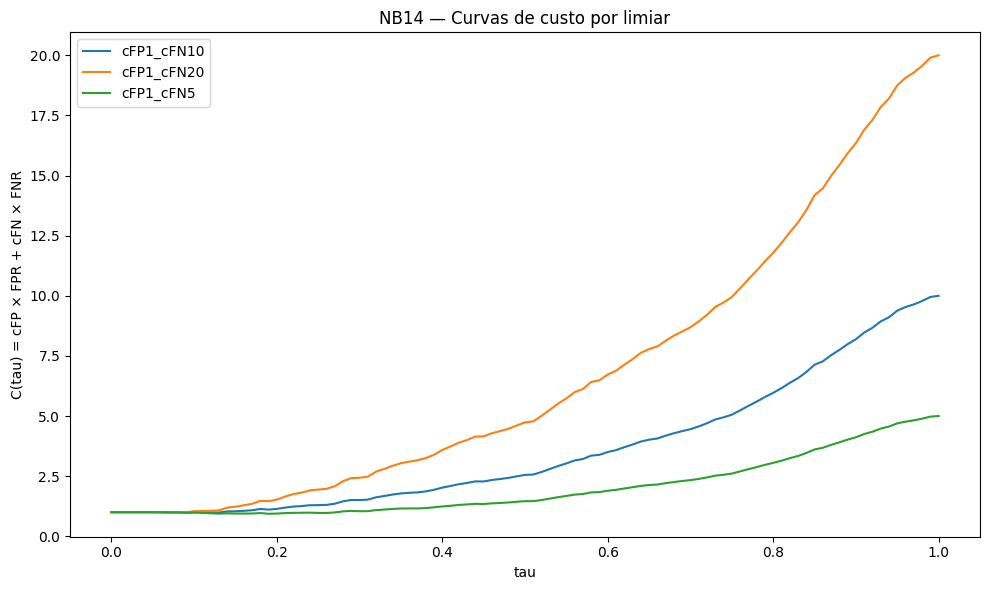

[2026-05-27 14:35:02] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb14/14_fig01_cost_curves.png


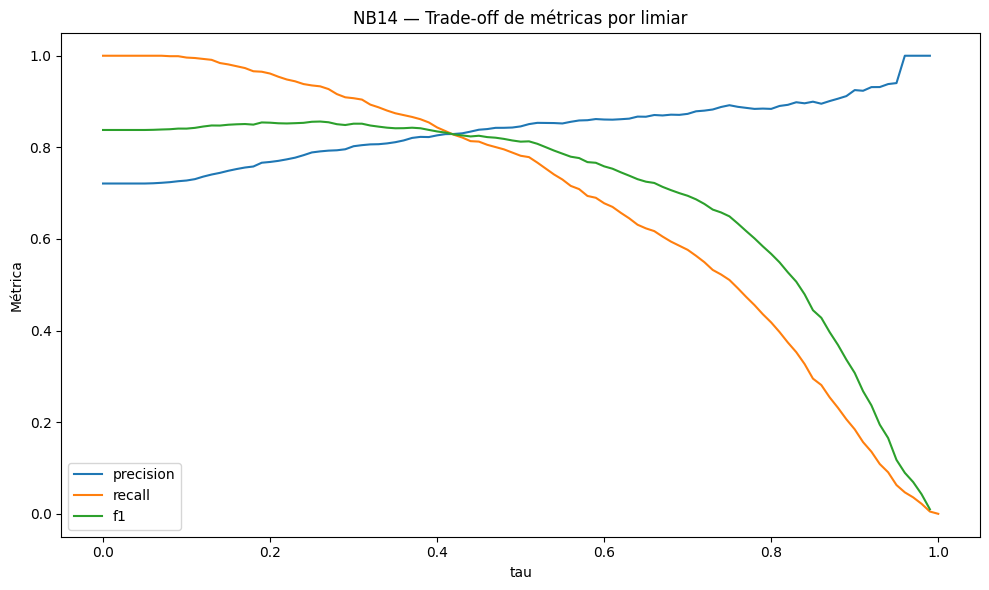

[2026-05-27 14:35:02] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb14/14_fig02_tau_metrics_tradeoff.png


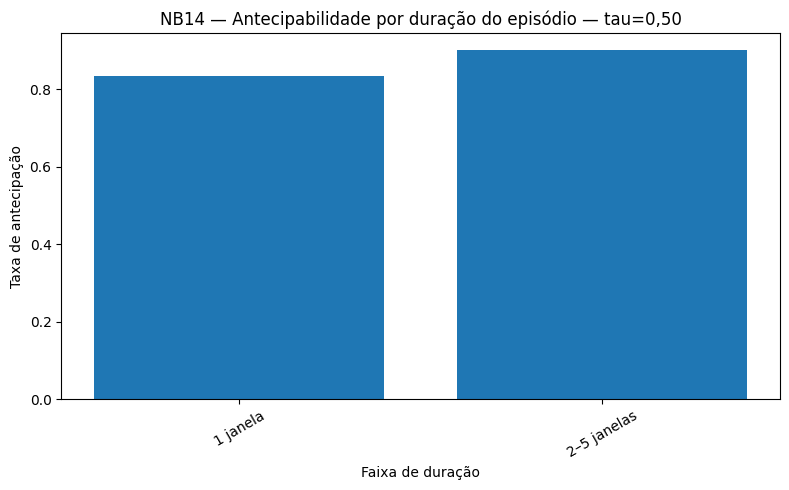

[2026-05-27 14:35:03] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb14/14_fig03_duration_anticipability.png


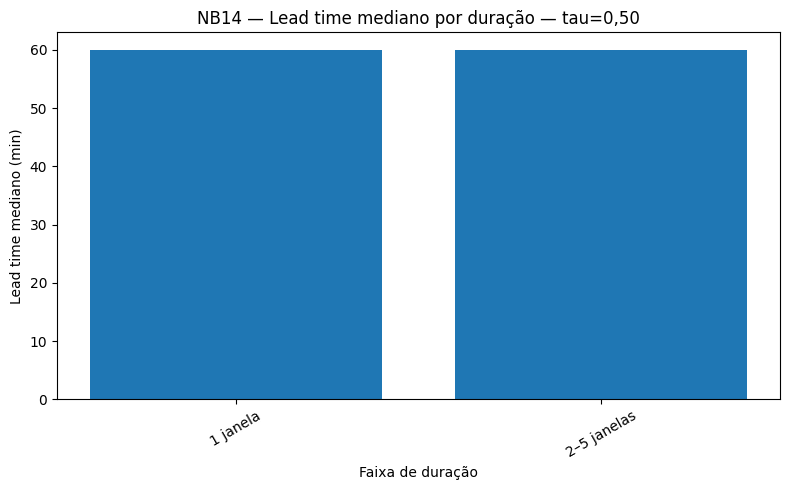

[2026-05-27 14:35:04] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb14/14_fig04_lead_time_by_duration.png


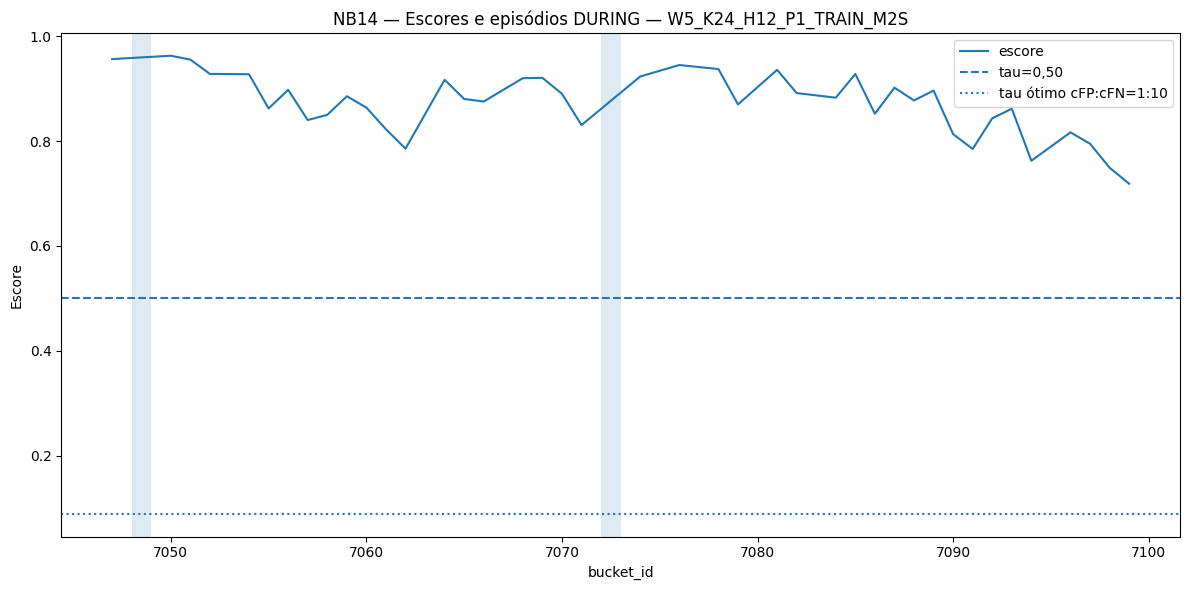

[2026-05-27 14:35:04] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb14/14_fig05_timeline_scores_main.png

NB14 concluído.

Artefatos gerados:


,artifact,path,exists
0,scores_selected,/content/drive/MyDrive/Mestrado/04-reports/14_...,True
1,threshold_metrics,/content/drive/MyDrive/Mestrado/04-reports/14_...,True
2,cost_curve,/content/drive/MyDrive/Mestrado/04-reports/14_...,True
3,optimal_tau,/content/drive/MyDrive/Mestrado/04-reports/14_...,True
4,false_alerts,/content/drive/MyDrive/Mestrado/04-reports/14_...,True
5,episode_anticipability_by_tau,/content/drive/MyDrive/Mestrado/04-reports/14_...,True
6,episode_anticipability,/content/drive/MyDrive/Mestrado/04-reports/14_...,True
7,episode_duration_summary,/content/drive/MyDrive/Mestrado/04-reports/14_...,True
8,scenario_summary,/content/drive/MyDrive/Mestrado/04-reports/14_...,True
9,summary_json,/content/drive/MyDrive/Mestrado/04-reports/14_...,True



Figuras geradas:


,figure,path,exists
0,cost_curve,/content/drive/MyDrive/Mestrado/04-reports/fig...,True
1,metrics_tradeoff,/content/drive/MyDrive/Mestrado/04-reports/fig...,True
2,duration_anticipability,/content/drive/MyDrive/Mestrado/04-reports/fig...,True
3,lead_time_by_duration,/content/drive/MyDrive/Mestrado/04-reports/fig...,True
4,timeline_scores,/content/drive/MyDrive/Mestrado/04-reports/fig...,True



Taus ótimos por razão de custo:


,scenario_label,tau,cost_label,c_fp,c_fn,cost,cost_normalized,fpr,fnr,precision,recall,f1,false_alerts_per_day,score_source,model,feature_set,optimality_rule
0,W5_K24_H12_P1_TRAIN_M2S,0.09,cFP1_cFN10,1.0,10.0,0.984197,0.089472,0.974227,0.000997,0.726087,0.999003,0.840957,78.263120,NB11_calibrated,logistic_regression,temporal_core,minimize_cFP_FPR_plus_cFN_FNR_then_low_FNR_low...
1,W5_K24_H12_P1_TRAIN_M2S,0.07,cFP1_cFN20,1.0,20.0,0.992268,0.047251,0.992268,0.000000,0.722622,1.000000,0.838980,79.712437,NB11_calibrated,logistic_regression,temporal_core,minimize_cFP_FPR_plus_cFN_FNR_then_low_FNR_low...
2,W5_K24_H12_P1_TRAIN_M2S,0.19,cFP1_cFN5,1.0,5.0,0.934786,0.155798,0.760309,0.034895,0.766429,0.965105,0.854369,61.078361,NB11_calibrated,logistic_regression,temporal_core,minimize_cFP_FPR_plus_cFN_FNR_then_low_FNR_low...
3,W5_K24_H12_P1_TRAIN_P95,0.15,cFP1_cFN10,1.0,10.0,0.996656,0.090605,0.996656,0.000000,0.782957,1.000000,0.878268,62.462882,NB12_sensitivity_fixed,logistic_regression,temporal_core,minimize_cFP_FPR_plus_cFN_FNR_then_low_FNR_low...
4,W5_K24_H12_P1_TRAIN_P95,0.15,cFP1_cFN20,1.0,20.0,0.996656,0.047460,0.996656,0.000000,0.782957,1.000000,0.878268,62.462882,NB12_sensitivity_fixed,logistic_regression,temporal_core,minimize_cFP_FPR_plus_cFN_FNR_then_low_FNR_low...
5,W5_K24_H12_P1_TRAIN_P95,0.26,cFP1_cFN5,1.0,5.0,0.955324,0.159221,0.876254,0.015814,0.801515,0.984186,0.883507,54.917031,NB12_sensitivity_fixed,logistic_regression,temporal_core,minimize_cFP_FPR_plus_cFN_FNR_then_low_FNR_low...



Sumário por cenário:


,scenario_label,is_main_scenario,is_p95_sensitivity,score_source,score_source_file,model,feature_set,n_scored_rows,n_total_episodes,duration_one_window_pct,tau_reference,precision_tau_reference,recall_tau_reference,f1_tau_reference,fpr_tau_reference,fnr_tau_reference,false_alerts_per_day_tau_reference,n_evaluable_episodes_tau_reference,n_anticipated_episodes_tau_reference,episode_anticipation_rate_tau_reference,lead_time_minutes_mean_tau_reference,lead_time_minutes_median_tau_reference,tau_opt_cFP1_cFN10,cost_opt_cFP1_cFN10,recall_at_opt_cFP1_cFN10,fpr_at_opt_cFP1_cFN10,fnr_at_opt_cFP1_cFN10,tau_opt_cFP1_cFN20,cost_opt_cFP1_cFN20,recall_at_opt_cFP1_cFN20,fpr_at_opt_cFP1_cFN20,fnr_at_opt_cFP1_cFN20,tau_opt_cFP1_cFN5,cost_opt_cFP1_cFN5,recall_at_opt_cFP1_cFN5,fpr_at_opt_cFP1_cFN5,fnr_at_opt_cFP1_cFN5
0,W5_K24_H12_P1_TRAIN_M2S,1,0,NB11_calibrated,/content/drive/MyDrive/Mestrado/04-reports/11_...,logistic_regression,temporal_core,1391,388,0.773196,0.5,0.845739,0.781655,0.812435,0.368557,0.218345,29.607477,34,29,0.852941,53.62069,60.0,0.09,0.984197,0.999003,0.974227,0.000997,0.07,0.992268,1.0,0.992268,0.0,0.19,0.934786,0.965105,0.760309,0.034895
1,W5_K24_H12_P1_TRAIN_P95,0,1,NB12_sensitivity_fixed,/content/drive/MyDrive/Mestrado/04-reports/12_...,logistic_regression,temporal_core,1374,471,0.762208,0.5,0.844203,0.866977,0.855438,0.575251,0.133023,36.052402,35,32,0.914286,52.34375,60.0,0.15,0.996656,1.000000,0.996656,0.000000,0.15,0.996656,1.0,0.996656,0.0,0.26,0.955324,0.984186,0.876254,0.015814



Todos os outputs declarados foram gerados.

Leitura preliminar: o NB14 gerou os insumos para transformar os escores em análise operacional de antecipabilidade e política de limiar tau. O EWMA causal do NB11 foi registrado apenas como baseline temporal comparativo, sem compor C(tau) nesta versão. A Conclusão da Etapa deve ser redigida depois da inspeção dos artefatos, continuando a numeração do Markdown inicial.


In [1]:
# ============================================================
# NB14 — Episódios, Antecipabilidade e Função de Custo C(tau)
# Pipeline PPCOMP/DM — Dissertação de Mestrado
#
# Célula única:
# - consome episódios e estados do NB10;
# - consome escores preferencialmente do NB11;
# - registra o EWMA causal do NB11 como baseline temporal comparativo,
#   sem usá-lo como política principal de C(tau);
# - usa NB13 apenas se ele tiver superado o NB11 pelo critério definido;
# - avalia antecipabilidade por episódio e por faixa de duração;
# - varre tau em [0,1] para diferentes razões cFP:cFN;
# - salva artefatos canônicos em 04-reports/;
# - salva figuras apenas em 04-reports/figures_nb14/.
# ============================================================

import os
import re
import json
import math
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

# ============================================================
# 0. Configuração geral
# ============================================================

RUN_TIMESTAMP = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
RUN_TIMESTAMP_FILE = datetime.now().strftime("%Y%m%d_%H%M%S")

def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

def log(msg):
    print(f"[{now_str()}] {msg}", flush=True)

def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

def read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, default=str)

IN_COLAB = "google.colab" in str(get_ipython()) if "get_ipython" in globals() else False
if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as exc:
        log(f"[AVISO] Não foi possível montar o Google Drive automaticamente: {exc}")

BASE_DIR = (
    Path("/content/drive/MyDrive/Mestrado")
    if Path("/content/drive/MyDrive/Mestrado").exists()
    else Path.cwd()
)

DATA_DIR = BASE_DIR / "02-datasets"
FEATURES_DIR = DATA_DIR / "03-features"
MODELS_DIR = BASE_DIR / "03-models"
REPORTS_DIR = ensure_dir(BASE_DIR / "04-reports")
FIGURES_DIR = ensure_dir(REPORTS_DIR / "figures_nb14")

CONFIG = {
    "main_scenario_default": "W5_K24_H12_P1_TRAIN_M2S",
    "include_p95_if_scores_exist": True,
    "p95_scenario_default": "W5_K24_H12_P1_TRAIN_P95",
    "tau_step": 0.01,
    "classification_reference_tau": 0.50,
    "cost_ratios": [
        {"cost_label": "cFP1_cFN5", "c_fp": 1.0, "c_fn": 5.0},
        {"cost_label": "cFP1_cFN10", "c_fp": 1.0, "c_fn": 10.0},
        {"cost_label": "cFP1_cFN20", "c_fp": 1.0, "c_fn": 20.0},
    ],
    "low_count_threshold_duration_bin": 5,
    "prefer_fixed_protocol_scores": True,
    "use_nb13_only_if_decision_allows": True,
    "min_delta_f1_lstm_to_replace_nb11": 0.03,
    "save_conclusion_notes_txt": True,
    "ewma_baseline_note": (
        "O EWMA causal foi incorporado no NB11 como baseline temporal suavizado e "
        "comparativo. No NB14 ele não é usado como escore principal nem como política "
        "de limiar em C(tau), pois isso exigiria uma série operacional própria "
        "score_ewma ou alert_ewma e abriria uma ramificação metodológica adicional."
    ),
}

TAU_GRID = np.round(
    np.arange(0.0, 1.0 + CONFIG["tau_step"] / 2, CONFIG["tau_step"]),
    4
)

OUTPUT_FILES = {
    "scores_selected": REPORTS_DIR / "14_scores_selected.parquet",
    "threshold_metrics": REPORTS_DIR / "14_threshold_metrics_by_tau.csv",
    "cost_curve": REPORTS_DIR / "14_cost_curve.csv",
    "optimal_tau": REPORTS_DIR / "14_optimal_tau_by_cost.csv",
    "false_alerts": REPORTS_DIR / "14_false_alerts_by_tau.csv",
    "episode_anticipability_by_tau": REPORTS_DIR / "14_episode_anticipability_by_tau.csv",
    "episode_anticipability": REPORTS_DIR / "14_episode_anticipability.csv",
    "episode_duration_summary": REPORTS_DIR / "14_episode_duration_summary.csv",
    "scenario_summary": REPORTS_DIR / "14_scenario_summary.csv",
    "summary_json": REPORTS_DIR / "14_nb14_summary.json",
    "conclusion_notes": REPORTS_DIR / "14_conclusion_notes.txt",
}

FIGURE_FILES = {
    "cost_curve": FIGURES_DIR / "14_fig01_cost_curves.png",
    "metrics_tradeoff": FIGURES_DIR / "14_fig02_tau_metrics_tradeoff.png",
    "duration_anticipability": FIGURES_DIR / "14_fig03_duration_anticipability.png",
    "lead_time_by_duration": FIGURES_DIR / "14_fig04_lead_time_by_duration.png",
    "timeline_scores": FIGURES_DIR / "14_fig05_timeline_scores_main.png",
}

log("=" * 100)
log("NB14 — Episódios, Antecipabilidade e Função de Custo C(tau)")
log(f"RUN_TIMESTAMP = {RUN_TIMESTAMP}")
log(f"BASE_DIR = {BASE_DIR}")
log(f"REPORTS_DIR = {REPORTS_DIR}")
log(f"FIGURES_DIR = {FIGURES_DIR}")
log("=" * 100)

# ============================================================
# 1. Localização de artefatos
# ============================================================

def find_file(filename, search_roots=None, required=True):
    if search_roots is None:
        search_roots = [
            REPORTS_DIR,
            REPORTS_DIR / "nb10",
            REPORTS_DIR / "nb11",
            REPORTS_DIR / "nb12",
            REPORTS_DIR / "nb13",
            BASE_DIR,
        ]

    direct_candidates = [Path(root) / filename for root in search_roots]
    for p in direct_candidates:
        if p.exists():
            return p

    for root in search_roots:
        root = Path(root)
        if root.exists():
            matches = sorted(
                root.rglob(filename),
                key=lambda x: x.stat().st_mtime,
                reverse=True
            )
            if matches:
                return matches[0]

    if required:
        msg = "Arquivo obrigatório não encontrado: " + filename + "\nCandidatos diretos:\n"
        msg += "\n".join(str(p) for p in direct_candidates)
        raise FileNotFoundError(msg)
    return None

# Entradas NB10
PATH_EPISODES = find_file("10_scenario_episodes.parquet", required=True)
PATH_STATES = find_file("10_scenario_series_states.parquet", required=True)
PATH_DECISIONS = find_file("10_scenario_decisions.csv", required=False)

# Entradas NB11
PATH_WINNER = find_file("11_winner_model.json", required=True)
PATH_NB11_SUMMARY = find_file("11_nb11_summary.json", required=False)
PATH_NB11_CALIBRATION = find_file("11_calibration_summary.csv", required=False)
PATH_NB11_SCORES_CAL = find_file("11_scores_calibrated.parquet", required=False)
PATH_NB11_SCORES_RAW = find_file("11_scores_raw.parquet", required=False)

# Entradas NB12, opcionais para sensibilidade p95
PATH_NB12_SCORES = find_file("12_scores_sensitivity_fixed.parquet", required=False)
PATH_NB12_REVIEW = find_file("12_train_p95_review.json", required=False)
PATH_NB12_SUMMARY = find_file("12_nb12_summary.json", required=False)

# Entradas NB13, opcionais e condicionais
PATH_NB13_SUMMARY = find_file("13_lstm_summary.json", required=False)
PATH_NB13_SCORES = find_file("13_lstm_scores.parquet", required=False)

log("Artefatos localizados:")
for name, path in {
    "10_scenario_episodes": PATH_EPISODES,
    "10_scenario_series_states": PATH_STATES,
    "10_scenario_decisions": PATH_DECISIONS,
    "11_winner_model": PATH_WINNER,
    "11_nb11_summary": PATH_NB11_SUMMARY,
    "11_calibration_summary": PATH_NB11_CALIBRATION,
    "11_scores_calibrated": PATH_NB11_SCORES_CAL,
    "11_scores_raw": PATH_NB11_SCORES_RAW,
    "12_scores_sensitivity_fixed": PATH_NB12_SCORES,
    "13_lstm_summary": PATH_NB13_SUMMARY,
    "13_lstm_scores": PATH_NB13_SCORES,
}.items():
    log(f"{name}: {path}")

# ============================================================
# 2. Funções de inferência de colunas e parsing
# ============================================================

def infer_column(df, candidates, required=True, label="coluna"):
    cols = list(df.columns)
    lower_map = {str(c).lower(): c for c in cols}

    for c in candidates:
        if c in df.columns:
            return c
        if str(c).lower() in lower_map:
            return lower_map[str(c).lower()]

    if required:
        raise ValueError(
            f"Não foi possível inferir {label}. "
            f"Candidatos: {candidates}. Colunas disponíveis: {cols}"
        )
    return None

def parse_scenario_label(label):
    label = str(label)
    m = re.match(
        r"W(?P<W>\d+)_K(?P<K>\d+)_H(?P<H>\d+)_P(?P<P>\d+)_(?P<threshold>.+)",
        label
    )
    if not m:
        return {
            "scenario_label": label,
            "window_minutes": np.nan,
            "k_windows": np.nan,
            "h_windows": np.nan,
            "persistence_min_windows": np.nan,
            "threshold_family": "unknown",
        }

    d = m.groupdict()
    return {
        "scenario_label": label,
        "window_minutes": int(d["W"]),
        "k_windows": int(d["K"]),
        "h_windows": int(d["H"]),
        "persistence_min_windows": int(d["P"]),
        "threshold_family": str(d["threshold"]).lower(),
    }

def get_window_minutes(label, fallback=5):
    try:
        return int(parse_scenario_label(label)["window_minutes"])
    except Exception:
        return int(fallback)

def get_h_windows(label, fallback=12):
    try:
        return int(parse_scenario_label(label)["h_windows"])
    except Exception:
        return int(fallback)

def duration_bucket_from_windows(duration_windows):
    if pd.isna(duration_windows):
        return "unknown"
    d = int(duration_windows)
    if d <= 1:
        return "1 janela"
    if 2 <= d <= 5:
        return "2–5 janelas"
    if 6 <= d <= 20:
        return "6–20 janelas"
    return ">20 janelas"

def duration_bucket_order(bucket):
    order = {
        "1 janela": 1,
        "2–5 janelas": 2,
        "6–20 janelas": 3,
        ">20 janelas": 4,
        "unknown": 99,
    }
    return order.get(str(bucket), 99)

def safe_div(num, den):
    den = float(den)
    if den == 0 or pd.isna(den):
        return np.nan
    return float(num) / den

def boolish_contains(value, patterns):
    s = str(value).lower()
    return any(p.lower() in s for p in patterns)

# ============================================================
# 3. Carregamento de metadados dos notebooks anteriores
# ============================================================

winner = read_json(PATH_WINNER)
nb11_summary = read_json(PATH_NB11_SUMMARY) if PATH_NB11_SUMMARY else {}
nb12_review = read_json(PATH_NB12_REVIEW) if PATH_NB12_REVIEW else {}
nb12_summary = read_json(PATH_NB12_SUMMARY) if PATH_NB12_SUMMARY else {}
nb13_summary = read_json(PATH_NB13_SUMMARY) if PATH_NB13_SUMMARY else {}

winner_from_summary = nb11_summary.get("winner", {}) if isinstance(nb11_summary, dict) else {}
MAIN_SCENARIO = (
    winner.get("scenario_label")
    or winner_from_summary.get("scenario_label")
    or CONFIG["main_scenario_default"]
)
P95_SCENARIO = (
    CONFIG["p95_scenario_default"]
    if "TRAIN_M2S" not in MAIN_SCENARIO
    else MAIN_SCENARIO.replace("TRAIN_M2S", "TRAIN_P95")
)

WINNER_MODEL = winner.get("model", winner_from_summary.get("model", "unknown"))
WINNER_FEATURE_SET = winner.get("feature_set", winner_from_summary.get("feature_set", "unknown"))
WINNER_F1_TSCV = winner.get("f1_tscv_mean", winner_from_summary.get("f1_tscv_mean", np.nan))

log("Referência metodológica herdada:")
log(f"MAIN_SCENARIO = {MAIN_SCENARIO}")
log(f"P95_SCENARIO  = {P95_SCENARIO}")
log(f"WINNER_MODEL = {WINNER_MODEL}")
log(f"WINNER_FEATURE_SET = {WINNER_FEATURE_SET}")
log(f"WINNER_F1_TSCV = {WINNER_F1_TSCV}")

# ============================================================
# 4. Decisão condicional sobre fonte de escores
# ============================================================

def extract_nested_values(obj):
    values = []
    if isinstance(obj, dict):
        for v in obj.values():
            values.extend(extract_nested_values(v))
    elif isinstance(obj, list):
        for v in obj:
            values.extend(extract_nested_values(v))
    else:
        values.append(obj)
    return values

def nb13_allows_replacement(summary):
    if not summary:
        return False, "13_lstm_summary.json ausente."

    all_values = [str(v).lower() for v in extract_nested_values(summary)]
    joined = " | ".join(all_values)

    if "keep_nb11_scores_for_nb14" in joined:
        return False, "NB13 registrou keep_nb11_scores_for_nb14."
    if "use_lstm_scores_for_nb14" in joined or "replace_nb11_scores_for_nb14" in joined:
        return True, "NB13 registrou uso dos escores LSTM para o NB14."

    delta_candidates = []
    for key in [
        "delta_f1_vs_nb11",
        "delta_vs_nb11",
        "f1_delta_vs_nb11",
        "best_delta_f1",
    ]:
        if key in summary:
            delta_candidates.append(summary.get(key))

    for section_key in ["comparison_with_nb11", "decision", "winner", "best_lstm"]:
        section = summary.get(section_key) if isinstance(summary, dict) else None
        if isinstance(section, dict):
            for key in [
                "delta_f1_vs_nb11",
                "delta_vs_nb11",
                "f1_delta_vs_nb11",
                "best_delta_f1",
            ]:
                if key in section:
                    delta_candidates.append(section.get(key))

    for delta in delta_candidates:
        try:
            if float(delta) >= CONFIG["min_delta_f1_lstm_to_replace_nb11"]:
                return True, f"Delta F1 LSTM vs NB11 = {float(delta):.4f}."
        except Exception:
            pass

    return False, "NB13 não apresentou evidência estruturada para substituir NB11."

USE_NB13, NB13_DECISION_REASON = nb13_allows_replacement(nb13_summary)

if CONFIG["use_nb13_only_if_decision_allows"] and USE_NB13 and PATH_NB13_SCORES:
    PRIMARY_SCORE_SOURCE = "NB13_LSTM"
    PRIMARY_SCORE_PATH = PATH_NB13_SCORES
elif PATH_NB11_SCORES_CAL:
    PRIMARY_SCORE_SOURCE = "NB11_calibrated"
    PRIMARY_SCORE_PATH = PATH_NB11_SCORES_CAL
elif PATH_NB11_SCORES_RAW:
    PRIMARY_SCORE_SOURCE = "NB11_raw"
    PRIMARY_SCORE_PATH = PATH_NB11_SCORES_RAW
else:
    raise FileNotFoundError(
        "Nenhum arquivo de escore disponível. Esperado 11_scores_calibrated.parquet "
        "ou 11_scores_raw.parquet; 13_lstm_scores.parquet só é aceito se NB13 superar NB11."
    )

log("Fonte primária de escores:")
log(f"PRIMARY_SCORE_SOURCE = {PRIMARY_SCORE_SOURCE}")
log(f"PRIMARY_SCORE_PATH = {PRIMARY_SCORE_PATH}")
log(f"NB13_DECISION_REASON = {NB13_DECISION_REASON}")

EWMA_BASELINE_NOTE = CONFIG["ewma_baseline_note"]
log("Nota metodológica sobre EWMA causal do NB11:")
log(EWMA_BASELINE_NOTE)

# ============================================================
# 5. Padronização dos escores
# ============================================================

def standardize_score_frame(df, source_name, source_path):
    df = df.copy()
    df = df.loc[:, ~df.columns.duplicated()].copy()

    scenario_col = infer_column(
        df,
        ["scenario_label", "scenario", "scenario_id", "config_label"],
        label="coluna de cenário nos escores",
    )

    time_col = infer_column(
        df,
        ["bucket_id", "time_order", "bucket", "row_end_bucket_id", "row_end_position"],
        label="coluna temporal nos escores",
    )

    y_col = infer_column(
        df,
        ["y_true", "y", "y_nb11", "y_nb12", "target", "label"],
        label="coluna alvo nos escores",
    )

    score_col = infer_column(
        df,
        [
            "score_calibrated",
            "y_score_calibrated",
            "calibrated_score",
            "score_platt",
            "score_isotonic",
            "score_raw",
            "y_score",
            "score",
            "probability",
            "proba",
            "score_lstm",
        ],
        label="coluna de escore",
    )

    protocol_col = infer_column(
        df,
        ["protocol", "validation", "split", "validation_protocol"],
        required=False,
        label="coluna de protocolo",
    )

    if CONFIG["prefer_fixed_protocol_scores"] and protocol_col:
        fixed_mask = df[protocol_col].astype(str).str.lower().str.contains("fixed|80_20|80/20", regex=True, na=False)
        if fixed_mask.sum() > 0:
            df = df[fixed_mask].copy()

    model_col = infer_column(df, ["model", "model_name", "estimator"], required=False, label="modelo")
    feature_set_col = infer_column(df, ["feature_set", "featureset"], required=False, label="feature set")
    fold_col = infer_column(df, ["fold"], required=False, label="fold")
    seed_col = infer_column(df, ["seed"], required=False, label="seed")
    window_col = infer_column(df, ["window_minutes", "W"], required=False, label="window_minutes")
    h_col = infer_column(df, ["h_windows", "H", "horizon_h"], required=False, label="h_windows")

    out = pd.DataFrame({
        "scenario_label": df[scenario_col].astype(str),
        "bucket_id": pd.to_numeric(df[time_col], errors="coerce"),
        "y_true": pd.to_numeric(df[y_col], errors="coerce"),
        "score": pd.to_numeric(df[score_col], errors="coerce"),
    })

    out["score_source"] = source_name
    out["score_source_file"] = str(source_path)
    out["original_score_column"] = score_col
    out["protocol"] = df[protocol_col].astype(str).values if protocol_col else "unknown"
    out["model"] = df[model_col].astype(str).values if model_col else WINNER_MODEL
    out["feature_set"] = df[feature_set_col].astype(str).values if feature_set_col else WINNER_FEATURE_SET
    out["fold"] = df[fold_col].values if fold_col else np.nan
    out["seed"] = df[seed_col].values if seed_col else np.nan

    if window_col:
        out["window_minutes"] = pd.to_numeric(df[window_col], errors="coerce").values
    else:
        out["window_minutes"] = out["scenario_label"].map(lambda s: get_window_minutes(s, fallback=5))

    if h_col:
        out["h_windows"] = pd.to_numeric(df[h_col], errors="coerce").values
    else:
        out["h_windows"] = out["scenario_label"].map(lambda s: get_h_windows(s, fallback=12))

    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.dropna(subset=["scenario_label", "bucket_id", "y_true", "score"])
    out["bucket_id"] = out["bucket_id"].astype(int)
    out["y_true"] = out["y_true"].astype(int)
    out["score"] = out["score"].clip(0.0, 1.0)

    # Se houver múltiplas sementes/folds/configurações para o mesmo bucket,
    # usa média dos escores e conserva y_true máximo como defesa.
    group_cols = ["scenario_label", "bucket_id"]
    agg = {
        "y_true": "max",
        "score": "mean",
        "score_source": "first",
        "score_source_file": "first",
        "original_score_column": "first",
        "protocol": lambda x: "|".join(sorted(set(map(str, x))))[:200],
        "model": lambda x: "|".join(sorted(set(map(str, x))))[:200],
        "feature_set": lambda x: "|".join(sorted(set(map(str, x))))[:200],
        "window_minutes": "first",
        "h_windows": "first",
    }
    out = out.groupby(group_cols, as_index=False).agg(agg)
    out["window_minutes"] = out["window_minutes"].fillna(out["scenario_label"].map(lambda s: get_window_minutes(s, 5))).astype(int)
    out["h_windows"] = out["h_windows"].fillna(out["scenario_label"].map(lambda s: get_h_windows(s, 12))).astype(int)

    parsed = out["scenario_label"].apply(parse_scenario_label).apply(pd.Series)
    for c in parsed.columns:
        if c not in out.columns:
            out[c] = parsed[c]

    return out.sort_values(["scenario_label", "bucket_id"]).reset_index(drop=True)

df_primary_scores_raw = pd.read_parquet(PRIMARY_SCORE_PATH)
df_scores_primary = standardize_score_frame(
    df_primary_scores_raw,
    source_name=PRIMARY_SCORE_SOURCE,
    source_path=PRIMARY_SCORE_PATH
)

score_frames = [df_scores_primary]

# Inclui, quando existir, a sensibilidade p95 do NB12 sem deslocar o cenário principal.
if CONFIG["include_p95_if_scores_exist"] and PATH_NB12_SCORES:
    try:
        df_nb12_scores_raw = pd.read_parquet(PATH_NB12_SCORES)
        df_scores_nb12 = standardize_score_frame(
            df_nb12_scores_raw,
            source_name="NB12_sensitivity_fixed",
            source_path=PATH_NB12_SCORES
        )
        score_frames.append(df_scores_nb12)
        log("Escores de sensibilidade do NB12 incluídos para comparação, quando aplicável.")
    except Exception as exc:
        log(f"[AVISO] Não foi possível padronizar escores do NB12: {exc}")

df_scores = pd.concat(score_frames, ignore_index=True)
df_scores = df_scores.drop_duplicates(
    subset=["scenario_label", "bucket_id", "score_source"],
    keep="first"
).copy()

available_score_scenarios = sorted(df_scores["scenario_label"].dropna().unique().tolist())
RUN_SCENARIOS = [s for s in [MAIN_SCENARIO, P95_SCENARIO] if s in available_score_scenarios]

if MAIN_SCENARIO not in RUN_SCENARIOS:
    log("[AVISO] Cenário principal não encontrado nos escores padronizados.")
    if available_score_scenarios:
        RUN_SCENARIOS = [available_score_scenarios[0]]
        log(f"[AVISO] Usando primeiro cenário disponível como fallback: {RUN_SCENARIOS[0]}")
    else:
        raise ValueError("Nenhum cenário disponível nos escores.")

df_scores = df_scores[df_scores["scenario_label"].isin(RUN_SCENARIOS)].copy()
df_scores.to_parquet(OUTPUT_FILES["scores_selected"], index=False)

log("Cenários avaliados no NB14:")
print(RUN_SCENARIOS)
log(f"df_scores padronizado: {df_scores.shape}")
display(df_scores.head())

# ============================================================
# 6. Padronização de episódios e estados
# ============================================================

df_episodes_raw = pd.read_parquet(PATH_EPISODES)
df_states_raw = pd.read_parquet(PATH_STATES)

scenario_col_ep = infer_column(
    df_episodes_raw,
    ["scenario_label", "scenario", "scenario_id", "config_label"],
    label="cenário em episódios",
)
start_col_ep = infer_column(
    df_episodes_raw,
    ["episode_start_bucket_id", "start_bucket_id", "start_bucket", "bucket_start", "start"],
    label="início do episódio",
)
end_col_ep = infer_column(
    df_episodes_raw,
    ["episode_end_bucket_id", "end_bucket_id", "end_bucket", "bucket_end", "end"],
    label="fim do episódio",
)

duration_col_ep = infer_column(
    df_episodes_raw,
    ["duration_windows", "episode_duration_windows", "n_windows", "length_windows"],
    required=False,
    label="duração em janelas",
)

def standardize_episodes(df):
    out = pd.DataFrame({
        "scenario_label": df[scenario_col_ep].astype(str),
        "episode_start_bucket_id": pd.to_numeric(df[start_col_ep], errors="coerce"),
        "episode_end_bucket_id": pd.to_numeric(df[end_col_ep], errors="coerce"),
    })
    out = out.dropna(subset=["episode_start_bucket_id", "episode_end_bucket_id"])
    out["episode_start_bucket_id"] = out["episode_start_bucket_id"].astype(int)
    out["episode_end_bucket_id"] = out["episode_end_bucket_id"].astype(int)

    if duration_col_ep:
        out["duration_windows"] = pd.to_numeric(df[duration_col_ep], errors="coerce").values
    else:
        out["duration_windows"] = out["episode_end_bucket_id"] - out["episode_start_bucket_id"] + 1

    out["duration_windows"] = out["duration_windows"].fillna(
        out["episode_end_bucket_id"] - out["episode_start_bucket_id"] + 1
    ).astype(int)

    parsed = out["scenario_label"].apply(parse_scenario_label).apply(pd.Series)
    for c in parsed.columns:
        if c not in out.columns:
            out[c] = parsed[c]

    out["window_minutes"] = out["window_minutes"].fillna(
        out["scenario_label"].map(lambda s: get_window_minutes(s, 5))
    ).astype(int)
    out["h_windows"] = out["h_windows"].fillna(
        out["scenario_label"].map(lambda s: get_h_windows(s, 12))
    ).astype(int)
    out["duration_minutes"] = out["duration_windows"] * out["window_minutes"]
    out["duration_bucket"] = out["duration_windows"].map(duration_bucket_from_windows)
    out["duration_bucket_order"] = out["duration_bucket"].map(duration_bucket_order)

    return out.sort_values(
        ["scenario_label", "episode_start_bucket_id", "episode_end_bucket_id"]
    ).reset_index(drop=True)

df_episodes = standardize_episodes(df_episodes_raw)
df_episodes = df_episodes[df_episodes["scenario_label"].isin(RUN_SCENARIOS)].copy()

scenario_col_states = infer_column(
    df_states_raw,
    ["scenario_label", "scenario", "scenario_id", "config_label"],
    label="cenário em estados",
)
state_col = infer_column(
    df_states_raw,
    ["state", "operational_state", "estado", "S"],
    required=False,
    label="estado operacional",
)
bucket_col_states = infer_column(
    df_states_raw,
    ["bucket_id", "bucket", "time_order"],
    label="bucket_id em estados",
)

df_states = df_states_raw[
    df_states_raw[scenario_col_states].astype(str).isin(RUN_SCENARIOS)
].copy()
df_states["scenario_label"] = df_states[scenario_col_states].astype(str)
df_states["bucket_id"] = pd.to_numeric(df_states[bucket_col_states], errors="coerce")
df_states = df_states.dropna(subset=["bucket_id"])
df_states["bucket_id"] = df_states["bucket_id"].astype(int)
if state_col:
    df_states["state_nb10"] = df_states[state_col].astype(str)
else:
    df_states["state_nb10"] = "unknown"

log(f"df_episodes padronizado: {df_episodes.shape}")
log(f"df_states padronizado: {df_states.shape}")
display(df_episodes.head())

# ============================================================
# 7. Métricas por tau e função de custo
# ============================================================

def confusion_counts(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    return tn, fp, fn, tp

def metrics_at_tau(scores_df, tau):
    y_true = scores_df["y_true"].astype(int).to_numpy()
    score = scores_df["score"].astype(float).to_numpy()
    y_pred = (score >= float(tau)).astype(int)

    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    n = len(y_true)
    positive_rate = safe_div(y_true.sum(), n)
    alert_rate = safe_div(y_pred.sum(), n)

    precision = safe_div(tp, tp + fp)
    recall = safe_div(tp, tp + fn)
    specificity = safe_div(tn, tn + fp)
    f1 = safe_div(2 * precision * recall, precision + recall) if not (pd.isna(precision) or pd.isna(recall)) else np.nan
    fpr = safe_div(fp, fp + tn)
    fnr = safe_div(fn, fn + tp)

    window_minutes = int(scores_df["window_minutes"].dropna().iloc[0]) if "window_minutes" in scores_df.columns and scores_df["window_minutes"].notna().any() else 5
    total_days = (n * window_minutes) / (60 * 24)

    return {
        "tau": float(tau),
        "n": int(n),
        "positive_rate": positive_rate,
        "alert_rate": alert_rate,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "accuracy": safe_div(tp + tn, n),
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "fpr": fpr,
        "fnr": fnr,
        "false_alerts": int(fp),
        "false_alerts_per_day": safe_div(fp, total_days),
        "window_minutes": int(window_minutes),
        "total_scored_days": float(total_days),
    }

threshold_rows = []
for scenario_label in RUN_SCENARIOS:
    s = df_scores[df_scores["scenario_label"] == scenario_label].copy()
    if s.empty:
        continue
    meta = parse_scenario_label(scenario_label)
    for tau in TAU_GRID:
        row = metrics_at_tau(s, tau)
        row.update({
            "scenario_label": scenario_label,
            "score_source": s["score_source"].iloc[0],
            "score_source_file": s["score_source_file"].iloc[0],
            "model": s["model"].iloc[0],
            "feature_set": s["feature_set"].iloc[0],
            **meta,
        })
        threshold_rows.append(row)

df_threshold_metrics = pd.DataFrame(threshold_rows)
df_threshold_metrics.to_csv(OUTPUT_FILES["threshold_metrics"], index=False)

cost_rows = []
for _, row in df_threshold_metrics.iterrows():
    for cr in CONFIG["cost_ratios"]:
        cost = cr["c_fp"] * row["fpr"] + cr["c_fn"] * row["fnr"]
        cost_norm = safe_div(cost, cr["c_fp"] + cr["c_fn"])
        cost_rows.append({
            "scenario_label": row["scenario_label"],
            "tau": row["tau"],
            "cost_label": cr["cost_label"],
            "c_fp": cr["c_fp"],
            "c_fn": cr["c_fn"],
            "cost": cost,
            "cost_normalized": cost_norm,
            "fpr": row["fpr"],
            "fnr": row["fnr"],
            "precision": row["precision"],
            "recall": row["recall"],
            "f1": row["f1"],
            "false_alerts_per_day": row["false_alerts_per_day"],
            "score_source": row["score_source"],
            "model": row["model"],
            "feature_set": row["feature_set"],
        })

df_cost_curve = pd.DataFrame(cost_rows)
df_cost_curve.to_csv(OUTPUT_FILES["cost_curve"], index=False)

optimal_rows = []
for (scenario_label, cost_label), grp in df_cost_curve.groupby(["scenario_label", "cost_label"]):
    opt = grp.sort_values(
        ["cost", "fnr", "fpr", "tau"],
        ascending=[True, True, True, True]
    ).iloc[0].to_dict()
    opt["optimality_rule"] = "minimize_cFP_FPR_plus_cFN_FNR_then_low_FNR_low_FPR_low_tau"
    optimal_rows.append(opt)

df_optimal_tau = pd.DataFrame(optimal_rows)
df_optimal_tau.to_csv(OUTPUT_FILES["optimal_tau"], index=False)

df_false_alerts = df_threshold_metrics[
    [
        "scenario_label",
        "tau",
        "false_alerts",
        "false_alerts_per_day",
        "alert_rate",
        "positive_rate",
        "fp",
        "tn",
        "fn",
        "tp",
        "score_source",
        "model",
        "feature_set",
    ]
].copy()
df_false_alerts.to_csv(OUTPUT_FILES["false_alerts"], index=False)

log("Métricas por tau e curvas de custo calculadas.")
display(df_optimal_tau.sort_values(["scenario_label", "cost_label"]))

# ============================================================
# 8. Antecipabilidade por episódio
# ============================================================

def compute_episode_detail_for_tau(episodes_s, scores_s, tau):
    scores_s = scores_s.sort_values("bucket_id").copy()
    score_lookup = dict(zip(scores_s["bucket_id"].astype(int), scores_s["score"].astype(float)))
    score_bucket_set = set(score_lookup.keys())

    rows = []
    for _, ep in episodes_s.iterrows():
        scenario_label = ep["scenario_label"]
        start = int(ep["episode_start_bucket_id"])
        end = int(ep["episode_end_bucket_id"])
        h_windows = int(ep.get("h_windows", get_h_windows(scenario_label, 12)))
        window_minutes = int(ep.get("window_minutes", get_window_minutes(scenario_label, 5)))

        previous_window = list(range(start - h_windows, start))
        available_previous = [b for b in previous_window if b in score_bucket_set]
        is_evaluable_full = len(available_previous) == h_windows
        is_evaluable_any = len(available_previous) > 0

        alert_buckets = [b for b in available_previous if score_lookup.get(b, -np.inf) >= float(tau)]
        if alert_buckets:
            first_alert_bucket = int(min(alert_buckets))
            lead_time_windows = int(start - first_alert_bucket)
            lead_time_minutes = int(lead_time_windows * window_minutes)
            anticipated_any = 1
            anticipated_full = int(is_evaluable_full)
        else:
            first_alert_bucket = np.nan
            lead_time_windows = np.nan
            lead_time_minutes = np.nan
            anticipated_any = 0
            anticipated_full = 0

        during_window = list(range(start, end + 1))
        available_during = [b for b in during_window if b in score_bucket_set]
        late_alert_buckets = [b for b in available_during if score_lookup.get(b, -np.inf) >= float(tau)]
        detected_during = int(len(late_alert_buckets) > 0)

        rows.append({
            "scenario_label": scenario_label,
            "tau": float(tau),
            "episode_start_bucket_id": start,
            "episode_end_bucket_id": end,
            "duration_windows": int(ep["duration_windows"]),
            "duration_minutes": int(ep["duration_minutes"]),
            "duration_bucket": ep["duration_bucket"],
            "duration_bucket_order": int(ep["duration_bucket_order"]),
            "window_minutes": window_minutes,
            "h_windows": h_windows,
            "available_previous_windows": int(len(available_previous)),
            "evaluable_full_horizon": int(is_evaluable_full),
            "evaluable_any_score": int(is_evaluable_any),
            "anticipated_full_horizon": int(anticipated_full),
            "anticipated_any_score": int(anticipated_any),
            "first_alert_bucket_id": first_alert_bucket,
            "lead_time_windows": lead_time_windows,
            "lead_time_minutes": lead_time_minutes,
            "detected_during": detected_during,
        })

    return pd.DataFrame(rows)

episode_tau_summary_rows = []
episode_detail_selected = []

for scenario_label in RUN_SCENARIOS:
    eps_s = df_episodes[df_episodes["scenario_label"] == scenario_label].copy()
    scores_s = df_scores[df_scores["scenario_label"] == scenario_label].copy()

    if eps_s.empty or scores_s.empty:
        continue

    # Sumário por todos os tau.
    for tau in TAU_GRID:
        detail = compute_episode_detail_for_tau(eps_s, scores_s, tau)
        total_episodes = len(detail)
        evaluable_full = int(detail["evaluable_full_horizon"].sum())
        anticipated_full = int(detail["anticipated_full_horizon"].sum())
        evaluable_any = int(detail["evaluable_any_score"].sum())
        anticipated_any = int(detail["anticipated_any_score"].sum())

        lead_full = detail[
            (detail["anticipated_full_horizon"] == 1)
            & detail["lead_time_minutes"].notna()
        ]

        episode_tau_summary_rows.append({
            "scenario_label": scenario_label,
            "tau": float(tau),
            "n_total_episodes": int(total_episodes),
            "n_evaluable_full_horizon": evaluable_full,
            "n_anticipated_full_horizon": anticipated_full,
            "episode_anticipation_rate_full_horizon": safe_div(anticipated_full, evaluable_full),
            "n_evaluable_any_score": evaluable_any,
            "n_anticipated_any_score": anticipated_any,
            "episode_anticipation_rate_any_score": safe_div(anticipated_any, evaluable_any),
            "lead_time_minutes_mean": float(lead_full["lead_time_minutes"].mean()) if not lead_full.empty else np.nan,
            "lead_time_minutes_median": float(lead_full["lead_time_minutes"].median()) if not lead_full.empty else np.nan,
            "lead_time_windows_mean": float(lead_full["lead_time_windows"].mean()) if not lead_full.empty else np.nan,
            "lead_time_windows_median": float(lead_full["lead_time_windows"].median()) if not lead_full.empty else np.nan,
        })

    # Detalhe por thresholds selecionados: tau=0,50 e taus ótimos.
    opt_taus_s = df_optimal_tau[df_optimal_tau["scenario_label"] == scenario_label]["tau"].dropna().unique().tolist()
    selected_taus = sorted(set([CONFIG["classification_reference_tau"]] + [float(t) for t in opt_taus_s]))
    for tau in selected_taus:
        detail = compute_episode_detail_for_tau(eps_s, scores_s, tau)
        cost_labels_for_tau = df_optimal_tau[
            (df_optimal_tau["scenario_label"] == scenario_label)
            & (np.isclose(df_optimal_tau["tau"].astype(float), float(tau)))
        ]["cost_label"].dropna().unique().tolist()
        detail["tau_role"] = (
            "reference_0.50"
            if np.isclose(tau, CONFIG["classification_reference_tau"])
            else "optimal_cost_tau"
        )
        detail["cost_labels_at_tau"] = "|".join(cost_labels_for_tau) if cost_labels_for_tau else ""
        episode_detail_selected.append(detail)

df_episode_tau_summary = pd.DataFrame(episode_tau_summary_rows)
df_episode_tau_summary.to_csv(OUTPUT_FILES["episode_anticipability_by_tau"], index=False)

df_episode_detail = (
    pd.concat(episode_detail_selected, ignore_index=True)
    if episode_detail_selected
    else pd.DataFrame()
)
df_episode_detail.to_csv(OUTPUT_FILES["episode_anticipability"], index=False)

# ============================================================
# 9. Estratificação duração × antecipabilidade
# ============================================================

duration_rows = []
if not df_episode_detail.empty:
    for (scenario_label, tau, tau_role, duration_bucket), grp in df_episode_detail.groupby(
        ["scenario_label", "tau", "tau_role", "duration_bucket"],
        dropna=False
    ):
        grp = grp.copy()
        n_total = int(len(grp))
        n_eval = int(grp["evaluable_full_horizon"].sum())
        n_ant = int(grp["anticipated_full_horizon"].sum())
        ant = grp[
            (grp["anticipated_full_horizon"] == 1)
            & grp["lead_time_minutes"].notna()
        ]
        duration_rows.append({
            "scenario_label": scenario_label,
            "tau": float(tau),
            "tau_role": tau_role,
            "duration_bucket": duration_bucket,
            "duration_bucket_order": int(grp["duration_bucket_order"].iloc[0]) if "duration_bucket_order" in grp.columns else duration_bucket_order(duration_bucket),
            "n_total_episodes": n_total,
            "n_evaluable_full_horizon": n_eval,
            "n_anticipated_full_horizon": n_ant,
            "episode_recall_by_duration": safe_div(n_ant, n_eval),
            "lead_time_minutes_mean": float(ant["lead_time_minutes"].mean()) if not ant.empty else np.nan,
            "lead_time_minutes_median": float(ant["lead_time_minutes"].median()) if not ant.empty else np.nan,
            "lead_time_windows_mean": float(ant["lead_time_windows"].mean()) if not ant.empty else np.nan,
            "lead_time_windows_median": float(ant["lead_time_windows"].median()) if not ant.empty else np.nan,
            "low_count_flag": int(n_eval < CONFIG["low_count_threshold_duration_bin"]),
            "interpretation_flag": (
                "descritivo_baixa_contagem"
                if n_eval < CONFIG["low_count_threshold_duration_bin"]
                else "avaliavel"
            ),
        })

df_duration_summary = pd.DataFrame(duration_rows)
if not df_duration_summary.empty:
    df_duration_summary = df_duration_summary.sort_values(
        ["scenario_label", "tau", "duration_bucket_order"]
    )
df_duration_summary.to_csv(OUTPUT_FILES["episode_duration_summary"], index=False)

log("Antecipabilidade por episódio e por faixa de duração calculada.")
display(df_episode_tau_summary.head())
display(df_duration_summary.head())

# ============================================================
# 10. Sumário por cenário
# ============================================================

scenario_rows = []
for scenario_label in RUN_SCENARIOS:
    scores_s = df_scores[df_scores["scenario_label"] == scenario_label].copy()
    eps_s = df_episodes[df_episodes["scenario_label"] == scenario_label].copy()
    threshold_ref = df_threshold_metrics[
        (df_threshold_metrics["scenario_label"] == scenario_label)
        & (np.isclose(df_threshold_metrics["tau"], CONFIG["classification_reference_tau"]))
    ]
    episode_ref = df_episode_tau_summary[
        (df_episode_tau_summary["scenario_label"] == scenario_label)
        & (np.isclose(df_episode_tau_summary["tau"], CONFIG["classification_reference_tau"]))
    ]

    opt_s = df_optimal_tau[df_optimal_tau["scenario_label"] == scenario_label].copy()
    opt_dict = {}
    for _, r in opt_s.iterrows():
        opt_dict[f"tau_opt_{r['cost_label']}"] = float(r["tau"])
        opt_dict[f"cost_opt_{r['cost_label']}"] = float(r["cost"])
        opt_dict[f"recall_at_opt_{r['cost_label']}"] = float(r["recall"]) if not pd.isna(r["recall"]) else np.nan
        opt_dict[f"fpr_at_opt_{r['cost_label']}"] = float(r["fpr"]) if not pd.isna(r["fpr"]) else np.nan
        opt_dict[f"fnr_at_opt_{r['cost_label']}"] = float(r["fnr"]) if not pd.isna(r["fnr"]) else np.nan

    row = {
        "scenario_label": scenario_label,
        "is_main_scenario": int(scenario_label == MAIN_SCENARIO),
        "is_p95_sensitivity": int(scenario_label == P95_SCENARIO),
        "score_source": scores_s["score_source"].iloc[0] if not scores_s.empty else "",
        "score_source_file": scores_s["score_source_file"].iloc[0] if not scores_s.empty else "",
        "model": scores_s["model"].iloc[0] if not scores_s.empty else "",
        "feature_set": scores_s["feature_set"].iloc[0] if not scores_s.empty else "",
        "n_scored_rows": int(len(scores_s)),
        "n_total_episodes": int(len(eps_s)),
        "duration_one_window_pct": safe_div((eps_s["duration_windows"] == 1).sum(), len(eps_s)) if not eps_s.empty else np.nan,
    }

    if not threshold_ref.empty:
        tr = threshold_ref.iloc[0]
        row.update({
            "tau_reference": float(CONFIG["classification_reference_tau"]),
            "precision_tau_reference": tr["precision"],
            "recall_tau_reference": tr["recall"],
            "f1_tau_reference": tr["f1"],
            "fpr_tau_reference": tr["fpr"],
            "fnr_tau_reference": tr["fnr"],
            "false_alerts_per_day_tau_reference": tr["false_alerts_per_day"],
        })

    if not episode_ref.empty:
        er = episode_ref.iloc[0]
        row.update({
            "n_evaluable_episodes_tau_reference": int(er["n_evaluable_full_horizon"]),
            "n_anticipated_episodes_tau_reference": int(er["n_anticipated_full_horizon"]),
            "episode_anticipation_rate_tau_reference": er["episode_anticipation_rate_full_horizon"],
            "lead_time_minutes_mean_tau_reference": er["lead_time_minutes_mean"],
            "lead_time_minutes_median_tau_reference": er["lead_time_minutes_median"],
        })

    row.update(opt_dict)
    scenario_rows.append(row)

df_scenario_summary = pd.DataFrame(scenario_rows)
df_scenario_summary.to_csv(OUTPUT_FILES["scenario_summary"], index=False)

log("Sumário por cenário:")
display(df_scenario_summary)

# ============================================================
# 11. Figuras
# ============================================================

def save_or_warn(fig_path):
    try:
        plt.tight_layout()
        plt.savefig(fig_path, dpi=200)
        plt.show()
        log(f"Figura salva: {fig_path}")
    except Exception as exc:
        log(f"[AVISO] Não foi possível salvar figura {fig_path}: {exc}")
        plt.close()

# Figura 1 — Curvas de custo por tau para o cenário principal
try:
    main_cost = df_cost_curve[df_cost_curve["scenario_label"] == MAIN_SCENARIO].copy()
    if main_cost.empty:
        main_cost = df_cost_curve[df_cost_curve["scenario_label"] == RUN_SCENARIOS[0]].copy()
    plt.figure(figsize=(10, 6))
    for cost_label, grp in main_cost.groupby("cost_label"):
        grp = grp.sort_values("tau")
        plt.plot(grp["tau"], grp["cost"], label=cost_label)
    plt.xlabel("tau")
    plt.ylabel("C(tau) = cFP × FPR + cFN × FNR")
    plt.title("NB14 — Curvas de custo por limiar")
    plt.legend()
    save_or_warn(FIGURE_FILES["cost_curve"])
except Exception as exc:
    log(f"[AVISO] Falha na figura de curvas de custo: {exc}")

# Figura 2 — Trade-off precisão, recall e F1 por tau no cenário principal
try:
    main_metrics = df_threshold_metrics[df_threshold_metrics["scenario_label"] == MAIN_SCENARIO].copy()
    if main_metrics.empty:
        main_metrics = df_threshold_metrics[df_threshold_metrics["scenario_label"] == RUN_SCENARIOS[0]].copy()
    main_metrics = main_metrics.sort_values("tau")
    plt.figure(figsize=(10, 6))
    for metric in ["precision", "recall", "f1"]:
        plt.plot(main_metrics["tau"], main_metrics[metric], label=metric)
    plt.xlabel("tau")
    plt.ylabel("Métrica")
    plt.title("NB14 — Trade-off de métricas por limiar")
    plt.legend()
    save_or_warn(FIGURE_FILES["metrics_tradeoff"])
except Exception as exc:
    log(f"[AVISO] Falha na figura de trade-off por tau: {exc}")

# Figura 3 — Antecipabilidade por faixa de duração
try:
    fig_df = df_duration_summary[
        (df_duration_summary["scenario_label"] == MAIN_SCENARIO)
        & (df_duration_summary["tau_role"] == "reference_0.50")
    ].copy()
    if fig_df.empty:
        fig_df = df_duration_summary[df_duration_summary["tau_role"] == "reference_0.50"].copy()
    if not fig_df.empty:
        fig_df = fig_df.sort_values("duration_bucket_order")
        plt.figure(figsize=(8, 5))
        plt.bar(fig_df["duration_bucket"], fig_df["episode_recall_by_duration"])
        plt.xlabel("Faixa de duração")
        plt.ylabel("Taxa de antecipação")
        plt.title("NB14 — Antecipabilidade por duração do episódio — tau=0,50")
        plt.xticks(rotation=30)
        save_or_warn(FIGURE_FILES["duration_anticipability"])
except Exception as exc:
    log(f"[AVISO] Falha na figura de duração × antecipabilidade: {exc}")

# Figura 4 — Lead time mediano por faixa de duração
try:
    fig_df = df_duration_summary[
        (df_duration_summary["scenario_label"] == MAIN_SCENARIO)
        & (df_duration_summary["tau_role"] == "reference_0.50")
    ].copy()
    if fig_df.empty:
        fig_df = df_duration_summary[df_duration_summary["tau_role"] == "reference_0.50"].copy()
    if not fig_df.empty:
        fig_df = fig_df.sort_values("duration_bucket_order")
        plt.figure(figsize=(8, 5))
        plt.bar(fig_df["duration_bucket"], fig_df["lead_time_minutes_median"])
        plt.xlabel("Faixa de duração")
        plt.ylabel("Lead time mediano (min)")
        plt.title("NB14 — Lead time mediano por duração — tau=0,50")
        plt.xticks(rotation=30)
        save_or_warn(FIGURE_FILES["lead_time_by_duration"])
except Exception as exc:
    log(f"[AVISO] Falha na figura de lead time por duração: {exc}")

# Figura 5 — Recorte temporal de escores, episódios e limiares
try:
    main_scenario_for_plot = MAIN_SCENARIO if MAIN_SCENARIO in RUN_SCENARIOS else RUN_SCENARIOS[0]
    scores_plot = df_scores[df_scores["scenario_label"] == main_scenario_for_plot].copy()
    eps_plot = df_episodes[df_episodes["scenario_label"] == main_scenario_for_plot].copy()

    if not scores_plot.empty:
        score_min = int(scores_plot["bucket_id"].min())
        score_max = int(scores_plot["bucket_id"].max())
        h_windows_plot = get_h_windows(main_scenario_for_plot, 12)

        eps_evaluable = eps_plot[
            (eps_plot["episode_start_bucket_id"] - h_windows_plot >= score_min)
            & (eps_plot["episode_start_bucket_id"] <= score_max)
        ].copy()

        if not eps_evaluable.empty:
            chosen_ep = eps_evaluable.iloc[0]
            start_plot = max(score_min, int(chosen_ep["episode_start_bucket_id"]) - 3 * h_windows_plot)
            end_plot = min(score_max, int(chosen_ep["episode_end_bucket_id"]) + 3 * h_windows_plot)
        else:
            start_plot = score_min
            end_plot = min(score_max, score_min + 300)

        seg = scores_plot[
            (scores_plot["bucket_id"] >= start_plot)
            & (scores_plot["bucket_id"] <= end_plot)
        ].copy()

        opt_main = df_optimal_tau[
            (df_optimal_tau["scenario_label"] == main_scenario_for_plot)
            & (df_optimal_tau["cost_label"] == "cFP1_cFN10")
        ]
        tau_opt_10 = float(opt_main["tau"].iloc[0]) if not opt_main.empty else CONFIG["classification_reference_tau"]

        plt.figure(figsize=(12, 6))
        plt.plot(seg["bucket_id"], seg["score"], label="escore")
        plt.axhline(CONFIG["classification_reference_tau"], linestyle="--", label="tau=0,50")
        plt.axhline(tau_opt_10, linestyle=":", label="tau ótimo cFP:cFN=1:10")

        eps_seg = eps_plot[
            (eps_plot["episode_end_bucket_id"] >= start_plot)
            & (eps_plot["episode_start_bucket_id"] <= end_plot)
        ].copy()
        for _, ep in eps_seg.iterrows():
            plt.axvspan(
                int(ep["episode_start_bucket_id"]),
                int(ep["episode_end_bucket_id"]),
                alpha=0.15
            )

        plt.xlabel("bucket_id")
        plt.ylabel("Escore")
        plt.title(f"NB14 — Escores e episódios DURING — {main_scenario_for_plot}")
        plt.legend()
        save_or_warn(FIGURE_FILES["timeline_scores"])
except Exception as exc:
    log(f"[AVISO] Falha na figura temporal de escores: {exc}")

# ============================================================
# 12. Sumário JSON e notas automáticas
# ============================================================

score_interpretation = (
    "escore_relativo_de_risco_temporal"
    if PRIMARY_SCORE_SOURCE in ["NB11_calibrated", "NB11_raw"]
    else "escore_lstm_sequencial"
)

if PATH_NB11_CALIBRATION and PRIMARY_SCORE_SOURCE == "NB11_calibrated":
    score_interpretation += "_com_calibracao_diagnostica"

generated_artifacts = {name: str(path) for name, path in OUTPUT_FILES.items()}
generated_figures = {name: str(path) for name, path in FIGURE_FILES.items()}


def collect_missing_outputs():
    """
    Verifica a existência de todos os artefatos declarados.

    Correção importante em relação à versão anterior:
    a verificação precisa ser feita depois da gravação de 14_conclusion_notes.txt
    e depois de pelo menos uma gravação de 14_nb14_summary.json. Caso contrário,
    o próprio JSON e o TXT aparecem falsamente como ausentes.
    """
    declared_paths = list(OUTPUT_FILES.values()) + list(FIGURE_FILES.values())
    return [str(path) for path in declared_paths if not Path(path).exists()]


def build_operational_reading(df_scenario_summary, df_threshold_metrics, df_episode_tau_summary):
    """
    Monta uma leitura operacional compacta para o JSON de rastreabilidade.

    Essa leitura não cria novo critério metodológico. Ela apenas explicita três
    denominadores distintos que precisam ficar claros na dissertação:
    1. episódios totais do cenário;
    2. episódios avaliáveis no trecho pontuado com horizonte H completo;
    3. janelas pontuadas positivas/negativas usadas nas métricas por tau.
    """
    readings = []
    if df_scenario_summary is None or df_scenario_summary.empty:
        return readings

    for _, r in df_scenario_summary.iterrows():
        scenario_label = str(r.get("scenario_label", ""))
        total_episodes = r.get("n_total_episodes", np.nan)
        evaluable_episodes = r.get("n_evaluable_episodes_tau_reference", np.nan)
        anticipated_episodes = r.get("n_anticipated_episodes_tau_reference", np.nan)

        tau_ref = float(r.get("tau_reference", CONFIG["classification_reference_tau"]))
        tm = df_threshold_metrics[
            (df_threshold_metrics["scenario_label"].astype(str) == scenario_label)
            & (np.isclose(df_threshold_metrics["tau"].astype(float), tau_ref))
        ]

        base = {
            "scenario_label": scenario_label,
            "tau_reference": tau_ref,
            "n_total_episodes": int(total_episodes) if pd.notna(total_episodes) else None,
            "n_evaluable_episodes_full_horizon": int(evaluable_episodes) if pd.notna(evaluable_episodes) else None,
            "n_anticipated_episodes_full_horizon": int(anticipated_episodes) if pd.notna(anticipated_episodes) else None,
            "evaluable_episodes_over_total": safe_div(evaluable_episodes, total_episodes),
            "anticipated_episodes_over_total": safe_div(anticipated_episodes, total_episodes),
            "anticipated_episodes_over_evaluable": safe_div(anticipated_episodes, evaluable_episodes),
            "lead_time_minutes_median": r.get("lead_time_minutes_median_tau_reference", np.nan),
            "duration_one_window_pct": r.get("duration_one_window_pct", np.nan),
            "interpretation": (
                "episodic_recall_uses_only_evaluable_episodes_with_full_previous_H; "
                "window_metrics_use_scored_rows_at_tau_reference"
            ),
        }

        if not tm.empty:
            t = tm.iloc[0]
            base.update({
                "n_scored_rows": int(t.get("n", 0)),
                "window_positive_rate": float(t.get("positive_rate", np.nan)),
                "alert_rate": float(t.get("alert_rate", np.nan)),
                "tp_windows": int(t.get("tp", 0)),
                "fp_windows": int(t.get("fp", 0)),
                "fn_windows": int(t.get("fn", 0)),
                "tn_windows": int(t.get("tn", 0)),
                "precision_windows": float(t.get("precision", np.nan)),
                "recall_windows": float(t.get("recall", np.nan)),
                "f1_windows": float(t.get("f1", np.nan)),
                "false_alerts_per_day": float(t.get("false_alerts_per_day", np.nan)),
            })
        readings.append(base)

    return readings


operational_reading = build_operational_reading(
    df_scenario_summary=df_scenario_summary,
    df_threshold_metrics=df_threshold_metrics,
    df_episode_tau_summary=df_episode_tau_summary,
)

# Summary inicial. O campo missing_outputs será atualizado depois da gravação
# dos próprios outputs de encerramento.
summary = {
    "notebook": "NB14",
    "title": "Episódios, Antecipabilidade e Função de Custo C(tau)",
    "run_timestamp": RUN_TIMESTAMP,
    "base_dir": str(BASE_DIR),
    "reports_dir": str(REPORTS_DIR),
    "figures_dir": str(FIGURES_DIR),
    "main_scenario": MAIN_SCENARIO,
    "p95_scenario": P95_SCENARIO,
    "run_scenarios": RUN_SCENARIOS,
    "winner_model_nb11": WINNER_MODEL,
    "winner_feature_set_nb11": WINNER_FEATURE_SET,
    "winner_f1_tscv_nb11": WINNER_F1_TSCV,
    "primary_score_source": PRIMARY_SCORE_SOURCE,
    "primary_score_path": str(PRIMARY_SCORE_PATH),
    "nb13_replacement_allowed": bool(USE_NB13),
    "nb13_decision_reason": NB13_DECISION_REASON,
    "ewma_baseline_registered_from_nb11": True,
    "ewma_used_as_primary_score_in_nb14": False,
    "ewma_used_in_cost_function_c_tau": False,
    "ewma_baseline_note": EWMA_BASELINE_NOTE,
    "score_interpretation": score_interpretation,
    "tau_grid": {
        "min": float(TAU_GRID.min()),
        "max": float(TAU_GRID.max()),
        "step": float(CONFIG["tau_step"]),
        "n": int(len(TAU_GRID)),
    },
    "cost_ratios": CONFIG["cost_ratios"],
    "duration_bins": ["1 janela", "2–5 janelas", "6–20 janelas", ">20 janelas"],
    "generated_artifacts": generated_artifacts,
    "generated_figures": generated_figures,
    "operational_reading_tau_reference": operational_reading,
    "missing_outputs": [],
    "n_missing_outputs": 0,
    "all_declared_outputs_exist": None,
    "methodological_notes": [
        "Tau é tratado como limiar sobre escore s(x).",
        "O EWMA causal do NB11 é registrado como baseline temporal suavizado e comparativo, não como escore principal do NB14.",
        "O EWMA não é incluído em C(tau) nesta versão porque isso exigiria série própria score_ewma ou alert_ewma e comparação explícita de políticas regra versus modelo.",
        "Quando a calibração não for satisfatória, tau deve ser interpretado como limiar sobre escore relativo de risco temporal.",
        "A taxa de antecipação primária usa episódios avaliáveis com horizonte anterior H completo nos escores disponíveis.",
        "O cenário train_p95, quando incluído, é sensibilidade forte e não substitui automaticamente train_m2s.",
        "As faixas de duração com baixa contagem devem ser lidas como evidência descritiva.",
        "As métricas por janela e por episódio usam denominadores diferentes e não devem ser confundidas.",
    ],
}

# Primeiro grava as notas textuais, porque elas também são declaradas como output.
if CONFIG["save_conclusion_notes_txt"]:
    lines = []
    lines.append("NB14 — Notas automáticas para posterior redação do Markdown final")
    lines.append(f"Execução: {RUN_TIMESTAMP}")
    lines.append("")
    lines.append(f"Cenário principal: {MAIN_SCENARIO}")
    lines.append(f"Fonte primária dos escores: {PRIMARY_SCORE_SOURCE}")
    lines.append(f"Interpretação dos escores: {score_interpretation}")
    lines.append(f"Decisão NB13: {NB13_DECISION_REASON}")
    lines.append("Nota EWMA/NB11: " + EWMA_BASELINE_NOTE)
    lines.append("Implicação: o NB14 preserva a separação entre baselines comparativos e política decisória baseada no escore operacional do modelo vencedor.")
    lines.append("")
    if not df_scenario_summary.empty:
        lines.append("Resumo por cenário:")
        for _, r in df_scenario_summary.iterrows():
            total_ep = r.get("n_total_episodes", np.nan)
            eval_ep = r.get("n_evaluable_episodes_tau_reference", np.nan)
            ant_ep = r.get("n_anticipated_episodes_tau_reference", np.nan)
            lines.append(f"- {r['scenario_label']}:")
            lines.append(f"  - linhas pontuadas: {r.get('n_scored_rows', np.nan)}")
            lines.append(f"  - episódios totais: {total_ep}")
            lines.append(f"  - episódios avaliáveis com H completo em tau=0,50: {eval_ep}")
            lines.append(f"  - episódios antecipados entre avaliáveis em tau=0,50: {ant_ep}")
            lines.append(f"  - % episódios de 1 janela: {r.get('duration_one_window_pct', np.nan)}")
            lines.append(f"  - recall tau=0,50: {r.get('recall_tau_reference', np.nan)}")
            lines.append(f"  - F1 tau=0,50: {r.get('f1_tau_reference', np.nan)}")
            lines.append(f"  - taxa de antecipação de episódios tau=0,50: {r.get('episode_anticipation_rate_tau_reference', np.nan)}")
            lines.append(f"  - lead time mediano tau=0,50: {r.get('lead_time_minutes_median_tau_reference', np.nan)} min")
            if pd.notna(total_ep) and float(total_ep) > 0 and pd.notna(ant_ep):
                lines.append(f"  - episódios antecipados / episódios totais: {float(ant_ep) / float(total_ep)}")
        lines.append("")
    lines.append("Observação: estas notas não substituem o Markdown final da etapa. O MD final deve ser escrito após inspeção do PDF, dos CSVs, dos Parquets e das figuras.")
    OUTPUT_FILES["conclusion_notes"].write_text("\n".join(lines), encoding="utf-8")

# Gravação inicial do summary para que o próprio JSON passe a existir.
save_json(summary, OUTPUT_FILES["summary_json"])

# Verificação final, agora depois que TXT e JSON já existem.
missing_outputs = collect_missing_outputs()
summary["missing_outputs"] = missing_outputs
summary["n_missing_outputs"] = int(len(missing_outputs))
summary["all_declared_outputs_exist"] = bool(len(missing_outputs) == 0)
summary["output_check_timestamp"] = now_str()

# Regrava o JSON com a checagem correta.
save_json(summary, OUTPUT_FILES["summary_json"])

# ============================================================
# 13. Relatório de encerramento da célula
# ============================================================

print("\n" + "=" * 100)
print("NB14 concluído.")
print("=" * 100)

print("\nArtefatos gerados:")
display(pd.DataFrame([
    {"artifact": name, "path": str(path), "exists": Path(path).exists()}
    for name, path in OUTPUT_FILES.items()
]))

print("\nFiguras geradas:")
display(pd.DataFrame([
    {"figure": name, "path": str(path), "exists": Path(path).exists()}
    for name, path in FIGURE_FILES.items()
]))

print("\nTaus ótimos por razão de custo:")
display(df_optimal_tau.sort_values(["scenario_label", "cost_label"]))

print("\nSumário por cenário:")
display(df_scenario_summary)

if missing_outputs:
    print("\n[AVISO] Alguns outputs esperados não foram encontrados:")
    for p in missing_outputs:
        print(" -", p)
else:
    print("\nTodos os outputs declarados foram gerados.")

print(
    "\nLeitura preliminar: o NB14 gerou os insumos para transformar os escores "
    "em análise operacional de antecipabilidade e política de limiar tau. "
    "O EWMA causal do NB11 foi registrado apenas como baseline temporal comparativo, "
    "sem compor C(tau) nesta versão. "
    "A Conclusão da Etapa deve ser redigida depois da inspeção dos artefatos, "
    "continuando a numeração do Markdown inicial."
)

# NB14 — Conclusão da Etapa

## 17. Fechamento da execução

O NB14 foi executado de forma adequada ao seu papel no pipeline PPCOMP/DM. A etapa conectou os escores preditivos produzidos nos notebooks anteriores a uma leitura operacional baseada em antecipabilidade, lead time, falsos alertas por unidade de tempo e função de custo \(C(\tau)\).

A execução utilizou como cenário principal `W5_K24_H12_P1_TRAIN_M2S` e incluiu, como sensibilidade forte, o cenário `W5_K24_H12_P1_TRAIN_P95`. Para o cenário principal, a fonte de escores permaneceu o artefato calibrado do NB11 (`11_scores_calibrated.parquet`). A decisão do NB13 foi preservada, pois a LSTM registrou `keep_nb11_scores_for_nb14`, não substituindo o modelo tabular vencedor do NB11 como fonte operacional preferencial de escores.

A execução corrigida também eliminou o falso aviso de artefatos ausentes. O arquivo `14_nb14_summary.json` registrou `missing_outputs = []`, `n_missing_outputs = 0` e `all_declared_outputs_exist = true`, indicando que os artefatos declarados pelo NB14 foram gerados conforme esperado.

## 18. Artefatos gerados e rastreabilidade

A etapa produziu os principais artefatos necessários para o fechamento da análise de decisão:

- `14_scores_selected.parquet`;
- `14_threshold_metrics_by_tau.csv`;
- `14_cost_curve.csv`;
- `14_optimal_tau_by_cost.csv`;
- `14_false_alerts_by_tau.csv`;
- `14_episode_anticipability_by_tau.csv`;
- `14_episode_anticipability.csv`;
- `14_episode_duration_summary.csv`;
- `14_scenario_summary.csv`;
- `14_nb14_summary.json`;
- `14_conclusion_notes.txt`.

As figuras foram registradas em `04-reports/figures_nb14/`, conforme o padrão definido para os notebooks finais da dissertação:

- `14_fig01_cost_curves.png`;
- `14_fig02_tau_metrics_tradeoff.png`;
- `14_fig03_duration_anticipability.png`;
- `14_fig04_lead_time_by_duration.png`;
- `14_fig05_timeline_scores_main.png`.

Essa organização preserva a rastreabilidade entre o notebook, os artefatos tabulares, o JSON de síntese e as figuras que poderão ser reaproveitadas no NB15 e consolidadas no NB16.

## 19. Interpretação dos escores

Embora o NB14 utilize escores calibrados do NB11 no cenário principal, a interpretação adotada permanece cautelosa. Os escores devem ser tratados como **escores relativos de risco temporal com calibração diagnóstica**, e não como probabilidades operacionais diretamente acionáveis.

Essa distinção é importante porque a calibração probabilística anterior não deve ser interpretada como garantia de probabilidade operacional absoluta. Assim, o limiar \(\tau\) deve ser entendido como um ponto de corte sobre um escore relativo \(s(x)\), útil para ordenar risco, priorizar janelas e apoiar decisão sob incerteza, mas ainda dependente de validação operacional, recalibração e análise de custos reais antes de qualquer uso automático em produção.

## 20. Registro metodológico sobre o EWMA causal

A inclusão do EWMA causal no NB11 foi devidamente preservada na rastreabilidade do NB14. O EWMA foi registrado como baseline temporal suavizado e comparativo, útil para reforçar a narrativa metodológica entre regras temporais simples, modelos supervisionados tabulares e modelos sequenciais mais complexos.

Entretanto, o EWMA não foi usado como escore principal no NB14 e não foi incluído diretamente na função de custo \(C(\tau)\). Essa decisão é adequada, pois o uso do EWMA como política decisória exigiria uma série operacional própria, como `score_ewma` ou `alert_ewma`, além de uma comparação explícita entre políticas baseadas em regra e políticas baseadas no modelo supervisionado.

Dessa forma, o NB14 preserva a separação entre:

1. baselines comparativos avaliados no NB11;
2. modelo supervisionado vencedor usado como fonte principal de escore;
3. análise decisória por limiar aplicada sobre o escore operacional escolhido.

## 21. Caracterização dos episódios críticos

No cenário principal `W5_K24_H12_P1_TRAIN_M2S`, foram considerados 388 episódios críticos. A distribuição de duração permaneceu fortemente concentrada em episódios curtos:

- 300 episódios de 1 janela, correspondendo a 77,3% do total;
- 85 episódios de 2 a 5 janelas, correspondendo a 21,9% do total;
- 3 episódios de 6 a 20 janelas, correspondendo a 0,8% do total.

Essa predominância de episódios de 1 janela confirma uma característica estrutural importante da série: a criticidade ocorre majoritariamente como picos curtos ou microepisódios. Por isso, a análise de antecipabilidade deve ser interpretada como evidência de sinal precursor em horizonte curto e controlado, e não como demonstração de previsão robusta de eventos longos e persistentes.

A faixa de 6 a 20 janelas teve apenas 3 episódios totais e nenhum episódio avaliável com horizonte anterior completo no trecho pontuado. Portanto, essa faixa deve permanecer apenas como evidência descritiva, sem inferência quantitativa.

## 22. Métricas por janela no limiar de referência \(\tau = 0{,}50\)

No cenário principal, em \(\tau = 0{,}50\), foram avaliadas 1.391 janelas pontuadas. A matriz de decisão por janela foi:

- verdadeiros positivos: 784;
- falsos positivos: 143;
- falsos negativos: 219;
- verdadeiros negativos: 245.

As métricas correspondentes foram:

- precisão: 84,6%;
- recall: 78,2%;
- F1-score: 81,2%;
- falsos alertas por dia: 29,6.

Esses resultados indicam que, no limiar de referência, a maioria dos alertas emitidos corresponde a janelas positivas na formulação supervisionada. Em termos operacionais, entretanto, os falsos alertas ainda precisam ser interpretados com cautela, pois são contabilizados por janela. Janelas consecutivas acima do limiar podem corresponder a um único evento operacional de alerta, e não necessariamente a múltiplos acionamentos independentes.

## 23. Antecipabilidade por episódio no limiar de referência

A taxa de antecipação por episódio usa denominador diferente das métricas por janela. Ela considera apenas episódios avaliáveis, isto é, episódios cujo intervalo anterior de \(H = 12\) janelas possuía escores disponíveis.

No cenário principal, em \(\tau = 0{,}50\):

- episódios totais no cenário: 388;
- episódios avaliáveis com horizonte anterior completo: 34;
- episódios antecipados entre os avaliáveis: 29;
- taxa de antecipação entre avaliáveis: 85,3%;
- episódios antecipados em relação ao total de episódios do cenário: 7,5%;
- lead time médio: 53,6 minutos;
- lead time mediano: 60,0 minutos.

A leitura correta é que o modelo antecipou 85,3% dos episódios avaliáveis no trecho pontuado, mas isso não deve ser traduzido como antecipação de 85,3% de todos os episódios críticos do cenário. Em relação ao total de episódios do cenário, os episódios antecipados no trecho avaliável representam 7,5%. Essa distinção deve ser preservada no relatório técnico e na dissertação.

Na estratificação por duração, em \(\tau = 0{,}50\), a taxa de antecipação entre episódios avaliáveis foi de 83,3% para episódios de 1 janela e 90,0% para episódios de 2 a 5 janelas. Esse resultado sugere que episódios um pouco mais longos podem ser mais antecipáveis, mas a conclusão deve ser mantida como descritiva, pois a quantidade de episódios avaliáveis ainda é reduzida.

## 24. Função de custo e limiares ótimos no cenário principal

A função de custo avaliada foi:

\[
C(\tau) = c_{FP} \cdot FPR(\tau) + c_{FN} \cdot FNR(\tau)
\]

Foram consideradas três razões de custo: `cFP1_cFN5`, `cFP1_cFN10` e `cFP1_cFN20`.

No cenário principal, os limiares ótimos identificados foram:

| Razão de custo | \(\tau^\*\) | Precisão | Recall | F1 | FPR | FNR | Falsos alertas/dia |
|---|---:|---:|---:|---:|---:|---:|---:|
| cFP1:cFN5 | 0,19 | 0,766 | 0,965 | 0,854 | 0,760 | 0,035 | 61,1 |
| cFP1:cFN10 | 0,09 | 0,726 | 0,999 | 0,841 | 0,974 | 0,001 | 78,3 |
| cFP1:cFN20 | 0,07 | 0,723 | 1,000 | 0,839 | 0,992 | 0,000 | 79,7 |

Como esperado, quanto maior o custo relativo do falso negativo, menor o limiar ótimo. Os limiares 0,07 e 0,09 praticamente eliminam falsos negativos, mas geram volume muito alto de falsos alertas por janela. O limiar 0,19 representa uma alternativa mais conservadora entre os limiares ótimos, mantendo recall elevado com menor volume relativo de falsos alertas.

Sob esses limiares otimizados por custo, a taxa de antecipação dos episódios avaliáveis chegou a 100% no cenário principal. Essa informação é relevante, mas deve ser sempre acompanhada da ressalva operacional sobre o aumento dos falsos alertas por janela.

## 25. Sensibilidade forte com `TRAIN_P95`

O cenário `W5_K24_H12_P1_TRAIN_P95` foi avaliado como sensibilidade forte, sem substituir automaticamente o cenário principal.

Em \(\tau = 0{,}50\), esse cenário apresentou:

- 471 episódios totais;
- 35 episódios avaliáveis com horizonte anterior completo;
- 32 episódios antecipados entre avaliáveis;
- taxa de antecipação entre avaliáveis: 91,4%;
- episódios antecipados em relação ao total: 6,8%;
- precisão por janela: 84,4%;
- recall por janela: 86,7%;
- F1-score por janela: 85,5%;
- falsos alertas por dia: 36,1;
- lead time mediano: 60 minutos.

Na função de custo, o cenário `TRAIN_P95` apresentou os seguintes limiares ótimos:

| Razão de custo | \(\tau^\*\) | Precisão | Recall | F1 | FPR | FNR | Falsos alertas/dia |
|---|---:|---:|---:|---:|---:|---:|---:|
| cFP1:cFN5 | 0,26 | 0,802 | 0,984 | 0,884 | 0,876 | 0,016 | 54,9 |
| cFP1:cFN10 | 0,15 | 0,783 | 1,000 | 0,878 | 0,997 | 0,000 | 62,5 |
| cFP1:cFN20 | 0,15 | 0,783 | 1,000 | 0,878 | 0,997 | 0,000 | 62,5 |

Esse resultado reforça o `TRAIN_P95` como sensibilidade forte e operacionalmente competitiva, especialmente porque atinge recall elevado e desempenho por janela superior em alguns pontos. Ainda assim, ele não substitui o cenário principal sem reabrir a regra metodológica definida no NB12.

## 26. Implicações operacionais

Os resultados do NB14 sugerem que os escores podem apoiar uma política de limiares múltiplos. Para fins de interpretação, três pontos de corte merecem destaque no cenário principal:

| Limiar | Papel interpretativo | Leitura operacional |
|---|---|---|
| \(\tau = 0{,}07\) | limiar altamente sensível | máxima cobertura, recall de 100%, falso negativo praticamente eliminado e alto volume de falsos alertas |
| \(\tau = 0{,}19\) | limiar de compromisso para cFP1:cFN5 | recall elevado, F1 superior entre os ótimos do cenário principal e menor volume relativo de falsos alertas entre os limiares otimizados |
| \(\tau = 0{,}50\) | referência de maior confiança | maior precisão e menor volume de falsos alertas, com perda de recall em relação aos limiares otimizados |

Esses limiares não devem ser interpretados como comandos automáticos de intervenção. Eles representam políticas candidatas de alerta, a serem calibradas com custos reais de operação, capacidade da equipe, criticidade do serviço, tolerância institucional a falsos positivos e necessidade de agregação de alertas contíguos.

A contagem de falsos alertas por dia é feita por janela. Portanto, antes de qualquer uso operacional, deve-se consolidar janelas consecutivas em eventos de alerta, reduzindo fadiga operacional e aproximando a métrica do fluxo real de chamados ou acionamentos.

## 27. Limitações da etapa

As principais limitações observadas no NB14 são:

1. o número de episódios avaliáveis com horizonte completo é reduzido em relação ao total de episódios do cenário;
2. a taxa de antecipação por episódio deve ser lida sobre episódios avaliáveis, e não sobre todos os episódios;
3. os escores permanecem como risco relativo, não como probabilidade operacional plenamente calibrada;
4. a maioria dos episódios tem duração de apenas 1 janela, o que limita a análise de persistência;
5. as faixas de duração mais longas têm baixa contagem ou ausência de casos avaliáveis;
6. os falsos alertas são contabilizados por janela e ainda precisam ser agregados em eventos operacionais;
7. os custos `cFP` e `cFN` são relativos e hipotéticos, não estimativas econômicas reais;
8. a função de custo é estática e não modela dependência temporal entre alertas consecutivos;
9. o cenário `TRAIN_P95` é competitivo, mas permanece subordinado à decisão metodológica do NB12;
10. o EWMA causal foi registrado como baseline comparativo, mas não foi avaliado como política decisória alternativa nesta versão.

## 28. Conclusão

O NB14 cumpriu seu papel no pipeline da dissertação ao transformar os escores preditivos em uma análise operacional de antecipabilidade, lead time e decisão por limiar.

O cenário principal `W5_K24_H12_P1_TRAIN_M2S` permanece metodologicamente defensável. Em \(\tau = 0{,}50\), apresentou boa precisão por janela, F1 elevado e antecipação de 85,3% dos episódios avaliáveis, com lead time mediano de 60 minutos. Sob limiares otimizados por custo, especialmente em \(\tau = 0{,}19\), o modelo alcançou 100% de antecipação dos episódios avaliáveis, com maior volume de falsos alertas por janela.

O cenário `TRAIN_P95` reforçou a robustez da formulação como sensibilidade forte, apresentando métricas competitivas e limiares de custo operacionalmente relevantes. Contudo, por coerência com a governança metodológica já definida, deve ser reportado como sensibilidade e não como substituto automático do cenário principal.

A conclusão científica mais adequada é que há evidência consistente de antecipabilidade no trecho pontuado e nos episódios avaliáveis, suficiente para sustentar a proposta como framework preditivo para apoio à decisão sob incerteza. A adoção operacional, entretanto, exigiria etapas adicionais de calibração, consolidação de alertas, validação em bases maiores e parametrização dos custos reais de falsos positivos e falsos negativos.

Com isso, o NB14 fornece os insumos necessários para o NB15, especialmente para a construção das figuras finais de escores, episódios, limiares e zonas de decisão, e para o NB16, que deverá consolidar rastreabilidade, achados, limitações e implicações finais da dissertação.
